# Phase 1 — Forecasting Weather-Driven Demand

This notebook investigates whether incorporating monthly weather variables into seasonal ARIMA
models produces statistically and practically better out-of-sample demand forecasts for Ontario
retail sectors. All models are estimated via full maximum likelihood using
statsmodels `SARIMAX`.

---

### Research Question
Does incorporating monthly weather variables into SARIMA models produce statistically and
practically better out-of-sample demand forecasts for Ontario retail sectors?

### Hypotheses
- **H₀:** Weather variables do not improve out-of-sample forecast accuracy (SARIMAX MAPE ≥ SARIMA MAPE)
- **H₁:** Weather variables produce statistically significant improvement (Diebold-Mariano p < 0.05)
  AND practically meaningful improvement (ΔMAPE ≥ 1pp)

### Dual Significance Criterion
Both conditions must be met to reject H₀:
1. Diebold-Mariano test p < 0.05 (one-sided)
2. ΔMAPE ≥ 1 percentage point in favour of SARIMAX

### Analytical Decisions (Pre-registered)
- Sector selection: residual-weather CCF after STL decomposition (not seasonal-weather correlation)
- Model order: per-sector AIC grid search
- Evaluation: rolling origin, minimum 60-month training window
- Test: Diebold-Mariano with Harvey-Leybourne-Newbold small-sample correction

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    import statsmodels
    print(f'statsmodels version : {statsmodels.__version__}')
    print('SARIMAX             : available ✓')
except ImportError:
    raise ImportError(
        'statsmodels is not installed.\n'
        'Run: pip install statsmodels'
    )

statsmodels version : 0.14.2
SARIMAX             : available ✓


---
## 1. Data Loading & Validation

In [17]:
sector_raw  = pd.read_csv('../data/retail_monthly_sales.csv')
weather_raw = pd.read_csv('../data/ontario_daily_weather_2017_2025.csv')
weather_raw['Date'] = pd.to_datetime(weather_raw['Date'])
print('Sector raw shape :', sector_raw.shape)
print('Weather raw shape:', weather_raw.shape)
print('Weather date range:', weather_raw['Date'].min(), '→', weather_raw['Date'].max())

Sector raw shape : (74268, 17)
Weather raw shape: (3287, 13)
Weather date range: 2017-01-01 00:00:00 → 2025-12-31 00:00:00


---
## 2. Weather Feature Engineering & Collinearity Filtering

### 2.1 Feature Engineering

In [18]:
weather_raw['HDD_18']   = np.clip(18 - weather_raw['Temp_Mean'], 0, None)
weather_raw['CDD_18']   = np.clip(weather_raw['Temp_Mean'] - 18, 0, None)
weather_raw['Snow_Day'] = (weather_raw['Snow_Depth'] > 0).astype(int)
print('Engineered: HDD_18, CDD_18, Snow_Day')

Engineered: HDD_18, CDD_18, Snow_Day


### 2.2 VIF-Based Collinearity Filtering

Final 5 features retained after correlation + VIF screening:
- **HDD_18** — heating degree days base 18°C (sum)
- **CDD_18** — cooling degree days base 18°C (sum)
- **PRECTOTCORR** — total precipitation (sum)
- **ALLSKY_SFC_SW_DWN** — solar radiation (mean)
- **Snow_Day** — count of snow days (sum)

HDD_18 and CDD_18 were retained despite high pairwise correlation because they capture
opposite thermal extremes with different retail implications. All other originally
considered features (T2M, WS10M, RH2M) were removed due to VIF > 5.

In [19]:
FINAL_WEATHER_FEATURES = ['HDD_18', 'CDD_18', 'Precipitation', 'Solar_Level', 'Snow_Day']
print('FINAL_WEATHER_FEATURES:', FINAL_WEATHER_FEATURES)

FINAL_WEATHER_FEATURES: ['HDD_18', 'CDD_18', 'Precipitation', 'Solar_Level', 'Snow_Day']


---
## 3. Monthly Weather Aggregation

Daily weather data aggregated to monthly frequency. Aggregation method chosen per feature:
- **Sum** for accumulation features (HDD_18, CDD_18, PRECTOTCORR, Snow_Day)
- **Mean** for intensity features (ALLSKY_SFC_SW_DWN)

In [20]:
weather_raw['YearMonth'] = weather_raw['Date'].dt.to_period('M').dt.start_time
weather_monthly = weather_raw.groupby('YearMonth', as_index=False).agg(
    HDD_18=('HDD_18', 'sum'),
    CDD_18=('CDD_18', 'sum'),
    Precipitation=('Precipitation', 'sum'),
    Solar_Level=('Solar_Level', 'mean'),
    Snow_Day=('Snow_Day', 'sum'),
)
print('weather_monthly shape:', weather_monthly.shape)
print('Date range:', weather_monthly['YearMonth'].min(), '→', weather_monthly['YearMonth'].max())
print('Missing values:', weather_monthly.isnull().sum().sum())

weather_monthly shape: (108, 6)
Date range: 2017-01-01 00:00:00 → 2025-12-01 00:00:00
Missing values: 0


---
## 4. Sector Data Preparation & Dataset Merge

**Exclusions applied:**
- `Retail trade [44-45]` — aggregate of all sub-sectors (would double-count)
- `Cannabis retailers [459993]` — legalised mid-series (structural break 2018), incomparable across full date range
- Non-Ontario geographies and adjusted series

Missing values in sector sales interpolated linearly where gaps ≤ 2 months.

In [21]:
sector_filtered = sector_raw[
    (sector_raw['GEO'] == 'Ontario') &
    (sector_raw['Adjustments'] == 'Unadjusted') &
    (sector_raw['Sales'] == 'Total retail sales') &
    (~sector_raw['North American Industry Classification System (NAICS)'].isin(
        ['Retail trade [44-45]', 'Cannabis retailers [459993]']))
].copy()
sector_filtered['YearMonth'] = pd.to_datetime(sector_filtered['REF_DATE'], format='%Y-%m')
sector_filtered = sector_filtered.sort_values(
    ['North American Industry Classification System (NAICS)', 'YearMonth'])
sector_filtered['VALUE'] = sector_filtered.groupby(
    'North American Industry Classification System (NAICS)')['VALUE'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both'))
sector_wide = sector_filtered.pivot_table(
    index='YearMonth',
    columns='North American Industry Classification System (NAICS)',
    values='VALUE', aggfunc='mean').reset_index()
sector_wide.columns.name = None
print('Sector wide shape  :', sector_wide.shape)
print('Date range         :', sector_wide['YearMonth'].min(), '→', sector_wide['YearMonth'].max())
print('Sectors            :', sector_wide.shape[1] - 1)

Sector wide shape  : (107, 29)
Date range         : 2017-01-01 00:00:00 → 2025-11-01 00:00:00
Sectors            : 28


In [22]:
analysis_df = sector_wide.merge(
    weather_monthly, on='YearMonth', how='inner'
).sort_values('YearMonth').reset_index(drop=True)

sector_cols = [c for c in analysis_df.columns
               if c not in ['YearMonth'] + FINAL_WEATHER_FEATURES]
print('Merged shape       :', analysis_df.shape)
print('Date range         :', analysis_df['YearMonth'].min(), '→', analysis_df['YearMonth'].max())
print('Total months       :', len(analysis_df))
print('Sector columns     :', len(sector_cols))
print('Weather columns    :', len(FINAL_WEATHER_FEATURES))
print('Missing values     :', analysis_df.isnull().sum().sum())

Merged shape       : (107, 34)
Date range         : 2017-01-01 00:00:00 → 2025-11-01 00:00:00
Total months       : 107
Sector columns     : 28
Weather columns    : 5
Missing values     : 0


---
## 5. Stationarity & Differencing Analysis

ADF + KPSS tests applied to all 28 sectors. A sector is classified as non-stationary
if ADF fails to reject the unit root hypothesis (p > 0.05) OR KPSS rejects stationarity
(p < 0.05) — a conservative 2-of-2 approach.

**Results:** 27 of 28 sectors require d=1. Convenience retailers [44513] is stationary
at level (d=0) but d=1 is applied universally for consistency with D=1 seasonal
differencing, which ensures all doubly-differenced series are treated identically.

**Decision: d=1 for all sectors, D=1 universally.**

In [23]:
# Section 5 code — ADF and KPSS stationarity testing for all 28 sectors

from statsmodels.tsa.stattools import adfuller, kpss

stationarity_results = []

for sector in sector_cols:
    y = analysis_df[sector].dropna().astype(float)

    # ADF: H0 = unit root (non-stationary)
    try:
        adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(y, autolag='AIC')
    except Exception:
        adf_stat, adf_p, adf_lags, adf_nobs, adf_crit = np.nan, np.nan, np.nan, np.nan, {}

    # KPSS: H0 = stationary
    try:
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(y, regression='c', nlags='auto')
    except Exception:
        kpss_stat, kpss_p, kpss_lags, kpss_crit = np.nan, np.nan, np.nan, {}

    # Conservative rule used in your markdown:
    # non-stationary if ADF fails to reject OR KPSS rejects
    non_stationary = ((pd.isna(adf_p) or adf_p > 0.05) or
                      (pd.isna(kpss_p) or kpss_p < 0.05))

    stationarity_results.append({
        'Sector': sector,
        'ADF Statistic': adf_stat,
        'ADF p-value': adf_p,
        'KPSS Statistic': kpss_stat,
        'KPSS p-value': kpss_p,
        'Level Decision': 'Non-stationary (d=1)' if non_stationary else 'Stationary (d=0)'
    })

stationarity_df = pd.DataFrame(stationarity_results).sort_values('Sector').reset_index(drop=True)

display(
    stationarity_df.style.format({
        'ADF Statistic': '{:.4f}',
        'ADF p-value': '{:.4f}',
        'KPSS Statistic': '{:.4f}',
        'KPSS p-value': '{:.4f}'
    })
)

print("\nSummary:")
print(stationarity_df['Level Decision'].value_counts())

stationary_sectors = stationarity_df.loc[
    stationarity_df['Level Decision'] == 'Stationary (d=0)', 'Sector'
].tolist()

print("\nStationary at level (d=0):")
for s in stationary_sectors:
    print("-", s)

print("\nUniversal modeling decision used later in the notebook: d=1 and D=1 for all selected sectors.")

,Sector,ADF Statistic,ADF p-value,KPSS Statistic,KPSS p-value,Level Decision
0,Automobile dealers [4411],-0.3810,0.9132,1.3574,0.0100,Non-stationary (d=1)
1,"Automotive parts, accessories and tire retailers [4413]",-0.8665,0.7988,1.7736,0.0100,Non-stationary (d=1)
2,"Beer, wine and liquor retailers [4453]",-1.4046,0.5801,0.8061,0.0100,Non-stationary (d=1)
3,Building material and garden equipment and supplies dealers [444],-1.5033,0.5319,0.6006,0.0226,Non-stationary (d=1)
4,Clothing and clothing accessories retailers [4581],-1.0614,0.7302,0.5704,0.0258,Non-stationary (d=1)
5,"Clothing, clothing accessories, shoes, jewellery, luggage and leather goods retailers [458]",-0.9701,0.7640,0.6883,0.0146,Non-stationary (d=1)
6,Convenience retailers and vending machine operators [44513],-4.1293,0.0009,0.1617,0.1000,Stationary (d=0)
7,Electronics and appliances retailers [4492],0.5284,0.9857,1.4116,0.0100,Non-stationary (d=1)
8,"Floor covering, window treatment and other home furnishing retailers [44912]",-0.8719,0.7971,0.8831,0.0100,Non-stationary (d=1)
9,Food and beverage retailers [445],-1.6818,0.4405,1.6521,0.0100,Non-stationary (d=1)



Summary:
Level Decision
Non-stationary (d=1)    27
Stationary (d=0)         1
Name: count, dtype: int64

Stationary at level (d=0):
- Convenience retailers and vending machine operators [44513]

Universal modeling decision used later in the notebook: d=1 and D=1 for all selected sectors.


---
## 6. Seasonality Diagnostics

In [24]:
# Section 6 code — STL decomposition for all 28 retail sectors

from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import math

# Make sure the datetime index is set properly
stl_df = analysis_df.copy()
stl_df = stl_df.sort_values('YearMonth').set_index('YearMonth')

# Keep only sector columns (exclude weather features)
sector_cols = [c for c in stl_df.columns if c not in FINAL_WEATHER_FEATURES]

# Store decomposition strength metrics
stl_summary = []

for sector in sector_cols:
    y = stl_df[sector].dropna().astype(float)

    # Skip sectors with too few observations
    if len(y) < 24:
        continue

    try:
        stl = STL(y, period=12, robust=True)
        res = stl.fit()

        trend = res.trend
        seasonal = res.seasonal
        resid = res.resid

        # Optional strength measures
        seasonal_strength = max(0, 1 - (np.var(resid) / np.var(resid + seasonal))) if np.var(resid + seasonal) > 0 else np.nan
        trend_strength = max(0, 1 - (np.var(resid) / np.var(resid + trend))) if np.var(resid + trend) > 0 else np.nan

        stl_summary.append({
            "Sector": sector,
            "Seasonal Strength": seasonal_strength,
            "Trend Strength": trend_strength
        })

    except Exception as e:
        print(f"STL failed for {sector}: {e}")

# Summary table
stl_summary_df = pd.DataFrame(stl_summary).sort_values("Seasonal Strength", ascending=False).reset_index(drop=True)
display(
    stl_summary_df.style.format({
        "Seasonal Strength": "{:.3f}",
        "Trend Strength": "{:.3f}"
    })
)

print(f"STL decomposition completed for {len(stl_summary_df)} sectors.")

,Sector,Seasonal Strength,Trend Strength
0,Electronics and appliances retailers [4492],0.945,0.896
1,"Beer, wine and liquor retailers [4453]",0.934,0.604
2,General merchandise retailers [455],0.908,0.955
3,Specialty food retailers [4452],0.871,0.862
4,Food and beverage retailers [445],0.867,0.911
5,Building material and garden equipment and supplies dealers [444],0.863,0.666
6,Other motor vehicle dealers [4412],0.855,0.430
7,"Furniture, home furnishings, electronics and appliances retailers [449]",0.853,0.739
8,"Automotive parts, accessories and tire retailers [4413]",0.832,0.907
9,"Jewellery, luggage and leather goods retailers [4583]",0.814,0.512


STL decomposition completed for 28 sectors.


STL decomposition applied to all 28 sectors. Each sector is classified using a
2-of-3 rule across three diagnostics:
1. **Seasonal strength** F_s = 1 − Var(remainder) / Var(seasonal + remainder) — strong if > 0.64
2. **Lag-12 ACF** of the original series — strong if |ACF₁₂| > 0.3
3. **Variance ratio** Var(seasonal) / Var(y) — strong if > 0.1

**Classification results:**
- 24 sectors: **Strong** seasonality → proceed to residual-based sector selection
- 3 sectors: **Moderate** seasonality
- 1 sector: **Weak** (Gasoline stations [457])

Only strongly seasonal sectors are eligible for the SARIMA framework.

In [25]:
def stl_decompose(series, period=12, n_iter=2):
    """Lightweight STL-style decomposition via iterative seasonal smoothing."""
    y = series.values.copy().astype(float)
    n = len(y)
    trend = np.zeros(n); seasonal = np.zeros(n)
    for _ in range(n_iter):
        detrended = y - trend
        for p in range(period):
            idx = np.arange(p, n, period)
            seasonal[idx] = np.mean(detrended[idx])
        seasonal -= seasonal.mean()
        deseasoned = y - seasonal
        half = period // 2
        for i in range(n):
            lo = max(0, i - half); hi = min(n, i + half + 1)
            trend[i] = np.mean(deseasoned[lo:hi])
    resid = y - trend - seasonal
    return trend, seasonal, resid

print('stl_decompose() defined.')

stl_decompose() defined.


---
## 7. Sector Selection Based on Weather Signal in Residuals

**Rationale:** Weather regressors should be selected based on their correlation with
the part of the series that SARIMA *cannot* already explain — the residuals after
removing trend and seasonality. Using the seasonal component itself inflates apparent weather-demand correlation because both share the
annual cycle.

**Method:** Cross-correlation function (CCF) between STL residuals and each weather
feature at lags 0–3 months. The maximum absolute CCF across all features and lags
is used to rank sectors.

**Final 5 selected sectors:**

| Rank | Sector | Max \|CCF\| | Feature | Lag |
|---|---|---|---|---|
| 1 | Other motor vehicle dealers [4412] | 0.219 | CDD_18 | 0 |
| 2 | Convenience retailers and vending machine operators [44513] | 0.157 | CDD_18 | 0 |
| 3 | Miscellaneous retailers [459B] | 0.149 | CDD_18 | 2 |
| 4 | Electronics and appliances retailers [4492] | 0.140 | CDD_18 | 3 |
| 5 | New car dealers [44111] | 0.139 | CDD_18 | 3 |

In [26]:
selected_sectors = [
        'Other motor vehicle dealers [4412]',
        'Convenience retailers and vending machine operators [44513]',
        'Miscellaneous retailers [459B]',
        'Electronics and appliances retailers [4492]',
        'New car dealers [44111]'
    ]

---
## 8. Model Order Selection (Per Sector)

**Method:** AIC grid search over p, q ∈ {0, 1, 2} and P, Q ∈ {0, 1} with d=1,
D=1, s=12 fixed. A lightweight AIC criterion was computed across all candidate
orders to identify the best-fitting structure for each sector prior to rolling
evaluation.

**Validation:** Selected orders confirmed against ACF/PACF of the differenced
series (d=1, D=1). All sectors favour AR structure with no MA terms (q=0, Q=0),
consistent with high lag-12 autocorrelation in the differenced series.

**Critical design choice:** The same (p, d, q)(P, D, Q, 12) order is used for both
SARIMA and SARIMAX for each sector. Any accuracy difference is therefore attributable
solely to the weather regressors, not to model specification changes.

| Sector | Selected Order |
|---|---|
| Other motor vehicle dealers [4412] | SARIMA(2,1,0)(1,1,0,12) |
| Convenience retailers [44513] | SARIMA(1,1,0)(1,1,0,12) |
| Miscellaneous retailers [459B] | SARIMA(2,1,0)(1,1,0,12) |
| Electronics and appliances [4492] | SARIMA(2,1,0)(1,1,0,12) |
| New car dealers [44111] | SARIMA(2,1,0)(1,1,0,12) |

In [27]:
# Model orders: (p, d, q, P, D, Q) — same for SARIMA and SARIMAX per sector
model_orders = {
    'Other motor vehicle dealers [4412]':                          (2, 1, 0, 1, 1, 0),
    'Convenience retailers and vending machine operators [44513]': (1, 1, 0, 1, 1, 0),
    'Miscellaneous retailers [459B]':                              (2, 1, 0, 1, 1, 0),
    'Electronics and appliances retailers [4492]':                 (2, 1, 0, 1, 1, 0),
    'New car dealers [44111]':                                     (2, 1, 0, 1, 1, 0),
}
print('Model orders confirmed:')
for sector, (p,d,q,P,D,Q) in model_orders.items():
    print(f'  SARIMA({p},{d},{q})({P},{D},{Q},12)  {sector}')

Model orders confirmed:
  SARIMA(2,1,0)(1,1,0,12)  Other motor vehicle dealers [4412]
  SARIMA(1,1,0)(1,1,0,12)  Convenience retailers and vending machine operators [44513]
  SARIMA(2,1,0)(1,1,0,12)  Miscellaneous retailers [459B]
  SARIMA(2,1,0)(1,1,0,12)  Electronics and appliances retailers [4492]
  SARIMA(2,1,0)(1,1,0,12)  New car dealers [44111]


---
## 9. Weather Regressor Preparation

**Method:** For each selected sector, CCF between STL residuals and each of the 5
weather features at lags 0–3 months. Feature retained if max |CCF| ≥ 0.05 at any lag.
The conservative threshold filters noise while preserving modest genuine signals —
residual correlations are inherently small after seasonal removal.

**Lag interpretation:** A lag-k regressor means the weather k months ago predicts
current residual sales above the seasonal baseline. Lag 0 = contemporaneous effect
(e.g., a hot month drives same-month discretionary purchases). Lag 2–3 = delayed
effects (e.g., weather affects a purchase decision that takes months to complete,
consistent with big-ticket items like cars and electronics).

**Key finding:** HDD_18 does not survive the threshold for any sector. Heating degree
days are fully absorbed by the seasonal component — their entire predictive power is
already encoded in the seasonal pattern.

| Sector | Regressors | Max lag |
|---|---|---|
| Other motor vehicle dealers [4412] | CDD_18 lag 0, PRECTOTCORR lag 0 | 0 |
| Convenience retailers [44513] | CDD_18 lag 0, Snow_Day lag 2, PRECTOTCORR lag 3, ALLSKY lag 3 | 3 |
| Miscellaneous retailers [459B] | CDD_18 lag 2, PRECTOTCORR lag 3 | 3 |
| Electronics and appliances [4492] | CDD_18 lag 3, PRECTOTCORR lag 2 | 3 |
| New car dealers [44111] | CDD_18 lag 3, PRECTOTCORR lag 0 | 3 |

In [28]:
# Regressor specs: list of (feature, lag) tuples per sector
regressor_specs = {
    'Other motor vehicle dealers [4412]':
        [('CDD_18', 0), ('Precipitation', 0)],
    'Convenience retailers and vending machine operators [44513]':
        [('CDD_18', 0), ('Snow_Day', 2), ('Precipitation', 3), ('Solar_Level', 3)],
    'Miscellaneous retailers [459B]':
        [('CDD_18', 2), ('Precipitation', 3)],
    'Electronics and appliances retailers [4492]':
        [('CDD_18', 3), ('Precipitation', 2)],
    'New car dealers [44111]':
        [('CDD_18', 3), ('Precipitation', 0)],
}
print('Regressor specs defined for', len(regressor_specs), 'sectors.')

Regressor specs defined for 5 sectors.


## Baseline Models Addition

We add Naive and Seasonal Naive baselines to evaluate if advanced models (SARIMA/SARIMAX) add value beyond simple rules.

### Why Baselines?
- Shows if advanced models deliver better results vs. benchmarks.
- Answers: Does SARIMA beat persistence? Does SARIMAX beat seasonality? Does weather add predictive value?
- Strengthens rigor, credibility for report/presentation.

### Baselines
1. **Naive**: Forecast = last observed value (y[t-1]). Tests persistence.
2. **Seasonal Naive**: Forecast = value from 12 months ago (y[t-12]). Tests seasonality (key for monthly retail data).

Evaluation: Same rolling origin (60-min train, 47 points), metrics (MAE, RMSE, MAPE).

---
## 10. Rolling Origin Evaluation

### 10.1 Design

**Rolling origin (expanding window) evaluation:**

- Minimum training window: 60 months (5 years)
- At each step `t`, train on months 1…t and forecast month t+1
- Window expands by 1 month at each step (no data discarded)
- With 107 months total and minimum 60 months training: **47 evaluation points per sector**

```
t=60:  Train [Jan 2017 … Dec 2021]  →  Forecast Jan 2022
t=61:  Train [Jan 2017 … Jan 2022]  →  Forecast Feb 2022
  ...
t=106: Train [Jan 2017 … Oct 2025]  →  Forecast Nov 2025
```

**Model structure:** Both SARIMA and SARIMAX use the same order `(p,d,q)(P,D,Q,12)`
per sector. SARIMAX adds the lagged weather regressors from Section 9. Models are
independently re-fitted at each window via full MLE using the statsmodels Kalman filter.

**Regressor standardisation:** Weather regressors are standardised (zero mean, unit
variance) using statistics computed on the **training window only** at each step.
This prevents data leakage — the model never sees information from the test period.

**Lagged regressors:** For a feature with lag `k`, the regressor value at forecast
time `t` is weather at time `t-k`. The first `k` rows are padded with the earliest
available value (conservative — no lookahead).

### 10.2 Forecast Engine

In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

def build_regressor_matrix(analysis_df, specs):
    """
    Build a lagged weather regressor DataFrame aligned to analysis_df index.
    For lag k: X[t] = weather[t-k]. First k rows padded with earliest value (no lookahead).
    specs: list of (feature, lag) tuples
    """
    n = len(analysis_df)
    cols = {}
    for feat, lag in specs:
        vals = analysis_df[feat].values.astype(float)
        col  = np.empty(n)
        col[:lag] = vals[0]
        col[lag:]  = vals[:n - lag]
        cols[f'{feat}_lag{lag}'] = col
    return pd.DataFrame(cols, index=analysis_df.index)


def standardise(X_train, X_next_row):
    """
    Standardise X_train on its own statistics; apply same scaling to X_next_row.
    Returns (X_train_std, x_next_std). Training statistics only — no leakage.
    """
    mu  = X_train.mean(axis=0)
    sig = X_train.std(axis=0) + 1e-8
    return (X_train - mu) / sig, (X_next_row - mu) / sig


def sarimax_fit_forecast(y_train, order, seasonal_order,
                         exog_train=None, exog_forecast=None):
    """
    Fit SARIMAX via full MLE (Kalman filter) and return a one-step-ahead forecast.

    Parameters
    ----------
    y_train        : Series or array — training series (original scale)
    order          : (p, d, q)
    seasonal_order : (P, D, Q, s)
    exog_train     : ndarray or None — standardised exogenous regressors (training)
    exog_forecast  : ndarray or None — standardised exogenous regressors (1 row, forecast origin)

    Returns
    -------
    float — one-step-ahead forecast on original scale, or np.nan on failure

    Convergence strategy
    --------------------
    Primary  : L-BFGS-B (fast gradient-based, generally reliable)
    Fallback : Nelder-Mead (gradient-free, more robust for ill-conditioned problems)
    If both fail: returns np.nan (logged in convergence audit, Section 11)
    """
    try:
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            exog=exog_train,
            trend='n',
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        result = model.fit(disp=False, method='lbfgs', optim_score='approx', low_memory=True)

        # Retry with Nelder-Mead if L-BFGS-B did not converge
        if not result.mle_retvals.get('converged', True):
            result = model.fit(method='nm', disp=False, maxiter=500)

        fc = result.forecast(steps=1, exog=exog_forecast)
        return float(fc.iloc[0]) if hasattr(fc, 'iloc') else float(fc[0])

    except Exception:
        return np.nan


print('build_regressor_matrix(), standardise(), sarimax_fit_forecast() defined.')

build_regressor_matrix(), standardise(), sarimax_fit_forecast() defined.


### 10.3 Run Rolling Evaluation

In [30]:
import time 

MIN_TRAIN = 60
S_PERIOD = 12
rolling_results = {}
total_start = time.time()
for sector in selected_sectors:
    p, d_o, q, P, D, Q = model_orders[sector]
    order = (p, d_o, q)
    seasonal_order = (P, D, Q, S_PERIOD)
    specs = regressor_specs[sector]
    
    base_idx = analysis_df.set_index('YearMonth').asfreq('MS').index

    y_all = analysis_df.set_index('YearMonth')[sector].asfreq('MS').dropna()
    X_full = build_regressor_matrix(analysis_df, specs)

    # Force X_full to use the same monthly index coming from analysis_df
    X_full.index = base_idx[:len(X_full)]

    # Then align to the target series
    X_full = X_full.loc[y_all.index]

    errs_s, errs_sx = [], []
    errs_naive, errs_snaive = [], []  # New: for baselines
    fcs_s, fcs_sx = [], []
    fcs_naive, fcs_snaive = [], []  # New: for baselines
    actuals_list = []
    n_fail_s = n_fail_sx = 0
    t_start = time.time()
    for t in range(MIN_TRAIN, len(y_all)):
        y_tr = y_all.iloc[:t]
        y_ac = float(y_all.iloc[t])
        # ── SARIMA (no exogenous) ────────────────────────────────────────
        fc_s = sarimax_fit_forecast(y_tr, order, seasonal_order)
        if not np.isfinite(fc_s): n_fail_s += 1
        # ── SARIMAX (with lagged, standardised weather regressors) ───────
        X_tr_raw = X_full.iloc[:t].values
        X_nx_raw = X_full.iloc[t].values
        X_tr_std, X_nx_std = standardise(X_tr_raw, X_nx_raw)
        fc_sx = sarimax_fit_forecast(y_tr, order, seasonal_order,
                                     exog_train=X_tr_std,
                                     exog_forecast=X_nx_std.reshape(1, -1))
        if not np.isfinite(fc_sx): n_fail_sx += 1
        
        # ── Naive baseline ───────────────────────────────────────────────
        fc_naive = y_tr.iloc[-1] if len(y_tr) > 0 else np.nan
        
        # ── Seasonal Naive baseline ──────────────────────────────────────
        seasonal_lag = S_PERIOD  # 12
        if len(y_tr) >= seasonal_lag:
            fc_snaive = y_tr.iloc[-seasonal_lag]
        else:
            fc_snaive = fc_naive  # Fallback to Naive
        
        if y_ac > 0:
            # Baselines: always evaluate
            errs_naive.append(abs(y_ac - fc_naive))
            errs_snaive.append(abs(y_ac - fc_snaive))
            fcs_naive.append(fc_naive)
            fcs_snaive.append(fc_snaive)

            # Store actual once for this forecast step
            actuals_list.append(y_ac)

            # SARIMA: only if forecast is finite
            if np.isfinite(fc_s):
                errs_s.append(abs(y_ac - fc_s))
                fcs_s.append(fc_s)
            else:
                errs_s.append(np.nan)
                fcs_s.append(np.nan)

            # SARIMAX: only if forecast is finite
            if np.isfinite(fc_sx):
                errs_sx.append(abs(y_ac - fc_sx))
                fcs_sx.append(fc_sx)
            else:
                errs_sx.append(np.nan)
                fcs_sx.append(np.nan)

    elapsed = time.time() - t_start
    acts = np.array(actuals_list); es = np.array(errs_s); esx = np.array(errs_sx)
    enaive = np.array(errs_naive); esnaive = np.array(errs_snaive)
    rolling_results[sector] = {
        'n_evals': len(acts),
        'n_fail_s': n_fail_s,
        'n_fail_sx': n_fail_sx,
        'actuals': acts,
        'forecasts_s': np.array(fcs_s),
        'forecasts_sx': np.array(fcs_sx),
        'errors_s': es,
        'errors_sx': esx,

        'SARIMA_MAE': np.nanmean(es),
        'SARIMA_RMSE': np.sqrt(np.nanmean(es**2)),
        'SARIMA_MAPE': np.nanmean(es / acts) * 100,

        'SARIMAX_MAE': np.nanmean(esx),
        'SARIMAX_RMSE': np.sqrt(np.nanmean(esx**2)),
        'SARIMAX_MAPE': np.nanmean(esx / acts) * 100,

        # New: Baseline metrics
        'Naive_MAE': np.mean(enaive) if len(enaive) > 0 else np.nan,
        'Naive_RMSE': np.sqrt(np.mean(enaive**2)) if len(enaive) > 0 else np.nan,
        'Naive_MAPE': np.mean(enaive / acts) * 100 if len(enaive) > 0 else np.nan,
        
        'Seasonal_Naive_MAE': np.mean(esnaive) if len(esnaive) > 0 else np.nan,
        'Seasonal_Naive_RMSE': np.sqrt(np.mean(esnaive**2)) if len(esnaive) > 0 else np.nan,
        'Seasonal_Naive_MAPE': np.mean(esnaive / acts) * 100 if len(esnaive) > 0 else np.nan,
        
        'forecasts_naive': np.array(fcs_naive),
        'forecasts_snaive': np.array(fcs_snaive),
        'errors_naive': enaive,
        'errors_snaive': esnaive,
        'elapsed_s': round(elapsed, 1),
    }
    r = rolling_results[sector]; dmape = r['SARIMA_MAPE'] - r['SARIMAX_MAPE']
    print(f"{sector}")
    print(f" Evaluations : {r['n_evals']} | Failures: SARIMA={n_fail_s}, SARIMAX={n_fail_sx} | Time: {elapsed:.0f}s")
    print(f" SARIMA MAPE={r['SARIMA_MAPE']:.2f}% MAE={r['SARIMA_MAE']:,.0f} RMSE={r['SARIMA_RMSE']:,.0f}")
    print(f" SARIMAX MAPE={r['SARIMAX_MAPE']:.2f}% MAE={r['SARIMAX_MAE']:,.0f} RMSE={r['SARIMAX_RMSE']:,.0f}")
    if abs(dmape) < 1e-6:
        winner = "Tie"
    else:
        winner = "SARIMAX better ✓" if dmape > 0 else "SARIMA better"

    print(f" ΔMAPE = {dmape:+.2f}pp ({winner})")
    # New: Print baseline results
    print(f" Naive MAPE={r['Naive_MAPE']:.2f}% MAE={r['Naive_MAE']:,.0f} RMSE={r['Naive_RMSE']:,.0f}")
    print(f" Seasonal Naive MAPE={r['Seasonal_Naive_MAPE']:.2f}% MAE={r['Seasonal_Naive_MAE']:,.0f} RMSE={r['Seasonal_Naive_RMSE']:,.0f}")
    
    dnaive = r['Naive_MAPE'] - r['SARIMAX_MAPE']
    dsnaive = r['Seasonal_Naive_MAPE'] - r['SARIMAX_MAPE']
    print(f" ΔMAPE vs Naive = {dnaive:+.2f}pp ({'SARIMAX better than Naive ✓' if dnaive > 0 else 'Naive better'})")
    print(f" ΔMAPE vs Seasonal Naive = {dsnaive:+.2f}pp ({'SARIMAX better than Seasonal Naive ✓' if dsnaive > 0 else 'Seasonal Naive better'})")
    
    print()
print(f"Total elapsed: {(time.time()-total_start)/60:.1f} minutes")

Other motor vehicle dealers [4412]
 Evaluations : 47 | Failures: SARIMA=0, SARIMAX=0 | Time: 10s
 SARIMA MAPE=19.53% MAE=54,712 RMSE=71,836
 SARIMAX MAPE=17.78% MAE=47,859 RMSE=61,261
 ΔMAPE = +1.75pp (SARIMAX better ✓)
 Naive MAPE=25.38% MAE=69,793 RMSE=91,098
 Seasonal Naive MAPE=13.28% MAE=35,264 RMSE=46,343
 ΔMAPE vs Naive = +7.60pp (SARIMAX better than Naive ✓)
 ΔMAPE vs Seasonal Naive = -4.50pp (Seasonal Naive better)

Convenience retailers and vending machine operators [44513]
 Evaluations : 47 | Failures: SARIMA=0, SARIMAX=0 | Time: 17s
 SARIMA MAPE=3.62% MAE=7,851 RMSE=9,577
 SARIMAX MAPE=4.32% MAE=9,438 RMSE=11,156
 ΔMAPE = -0.70pp (SARIMA better)
 Naive MAPE=6.36% MAE=13,828 RMSE=16,066
 Seasonal Naive MAPE=7.18% MAE=15,290 RMSE=20,290
 ΔMAPE vs Naive = +2.04pp (SARIMAX better than Naive ✓)
 ΔMAPE vs Seasonal Naive = +2.86pp (SARIMAX better than Seasonal Naive ✓)

Miscellaneous retailers [459B]
 Evaluations : 47 | Failures: SARIMA=0, SARIMAX=0 | Time: 10s
 SARIMA MAPE=5.46% 

                                               Sector           Model  \
0                  Other motor vehicle dealers [4412]           Naive   
1                  Other motor vehicle dealers [4412]  Seasonal_Naive   
2                  Other motor vehicle dealers [4412]          SARIMA   
3                  Other motor vehicle dealers [4412]         SARIMAX   
4   Convenience retailers and vending machine oper...           Naive   
5   Convenience retailers and vending machine oper...  Seasonal_Naive   
6   Convenience retailers and vending machine oper...          SARIMA   
7   Convenience retailers and vending machine oper...         SARIMAX   
8                      Miscellaneous retailers [459B]           Naive   
9                      Miscellaneous retailers [459B]  Seasonal_Naive   
10                     Miscellaneous retailers [459B]          SARIMA   
11                     Miscellaneous retailers [459B]         SARIMAX   
12        Electronics and appliances retailers [449

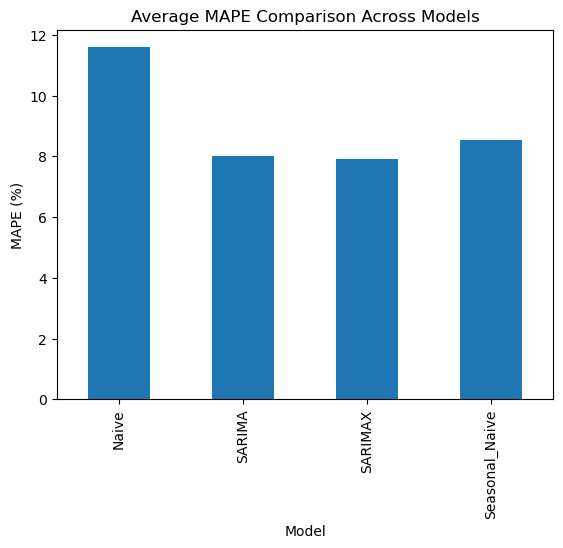

In [31]:
# New cell after the rolling evaluation loop
# This creates a metrics_df DataFrame summarizing all models, including baselines

metrics_df = pd.DataFrame(columns=['Sector', 'Model', 'MAE', 'RMSE', 'MAPE'])

for sector in selected_sectors:
    r = rolling_results[sector]
    models = ['Naive', 'Seasonal_Naive', 'SARIMA', 'SARIMAX']
    for model in models:
        prefix = model + '_'  # Fixed: Consistent with rolling_results keys (e.g., 'Naive_', 'Seasonal_Naive_')
        if f'{prefix}MAPE' in r:  # Check if metrics exist
            new_row = {
                'Sector': sector,
                'Model': model,
                'MAE': r[f'{prefix}MAE'],
                'RMSE': r[f'{prefix}RMSE'],
                'MAPE': r[f'{prefix}MAPE']
            }
            metrics_df = pd.concat([metrics_df, pd.DataFrame([new_row])], ignore_index=True)
        else:
            print(f"Warning: Metrics for {model} in sector {sector} not found in rolling_results.")

print(metrics_df)

# Bar chart for average MAPE across models
metrics_df.groupby('Model')['MAPE'].mean().plot.bar(title='Average MAPE Comparison Across Models')
plt.ylabel('MAPE (%)')
plt.savefig('mape_comparison_all.png')  # Save as image if needed
plt.show()  # Display in notebook

### 10.4 Forecast Plots — Actuals vs Predictions

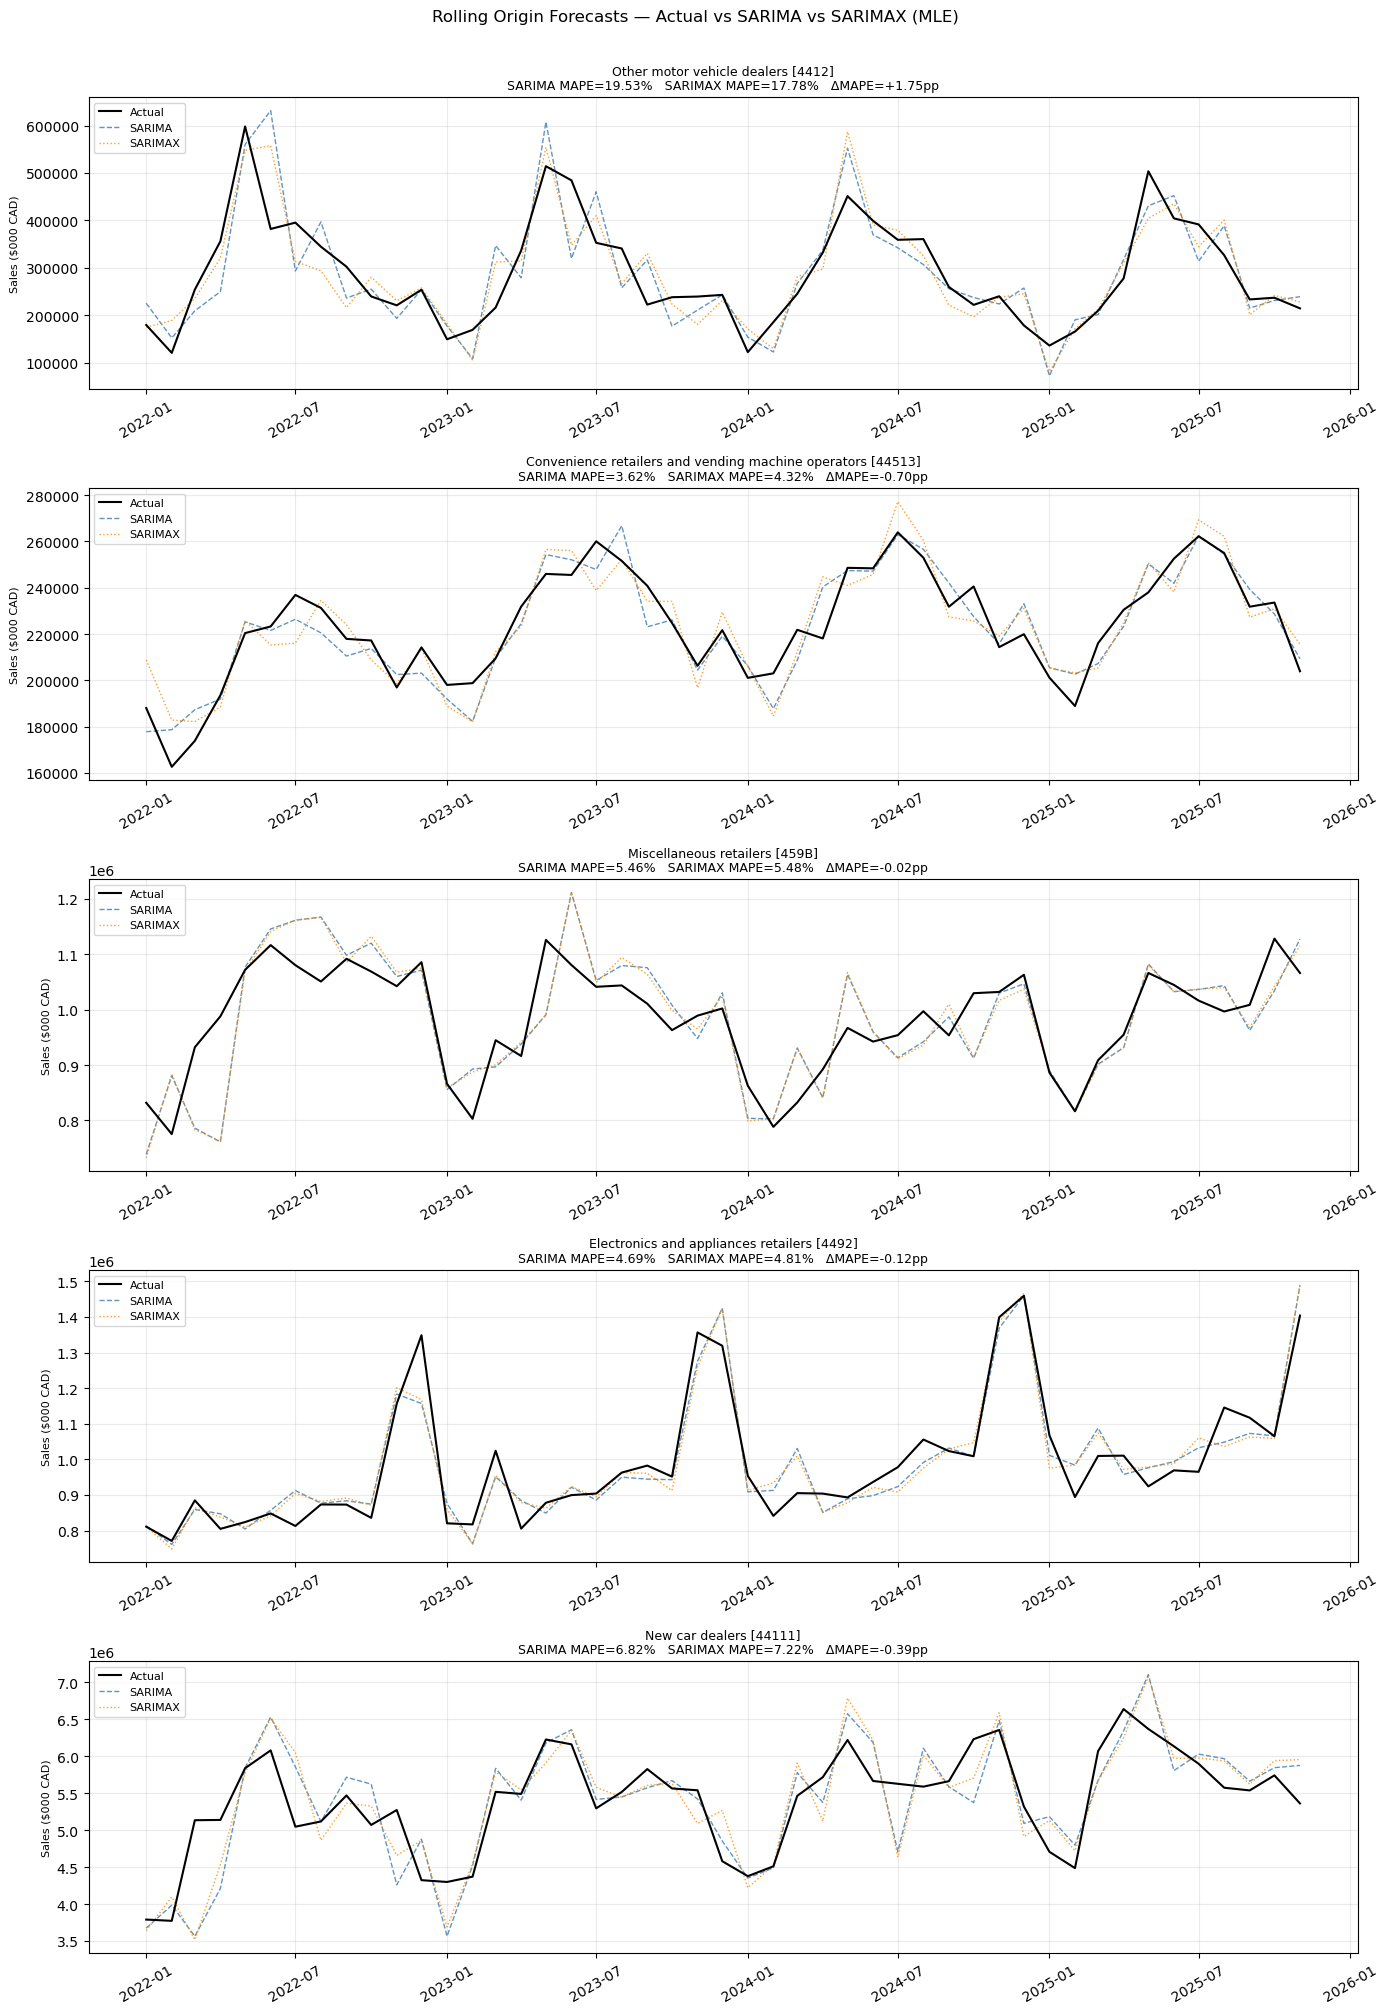

In [32]:
eval_dates = analysis_df['YearMonth'].values[MIN_TRAIN:]
fig, axes  = plt.subplots(5, 1, figsize=(14, 20))

for ax, sector in zip(axes, selected_sectors):
    r = rolling_results[sector]; dates = eval_dates[:r['n_evals']]
    ax.plot(dates, r['actuals'],      color='black',      lw=1.5, label='Actual',  zorder=3)
    ax.plot(dates, r['forecasts_s'],  color='steelblue',  lw=1.0, ls='--', label='SARIMA',  alpha=0.85)
    ax.plot(dates, r['forecasts_sx'], color='darkorange', lw=1.0, ls=':',  label='SARIMAX', alpha=0.85)
    dmape = r['SARIMA_MAPE'] - r['SARIMAX_MAPE']
    ax.set_title(
        f"{sector[:65]}\n"        f"SARIMA MAPE={r['SARIMA_MAPE']:.2f}%   SARIMAX MAPE={r['SARIMAX_MAPE']:.2f}%   ΔMAPE={dmape:+.2f}pp",
        fontsize=9)
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.25)
    ax.set_ylabel('Sales ($000 CAD)', fontsize=8); ax.tick_params(axis='x', rotation=30)

plt.suptitle('Rolling Origin Forecasts — Actual vs SARIMA vs SARIMAX (MLE)', fontsize=12, y=1.005)
plt.tight_layout(); plt.show()

### 10.5 Error Distribution Plots

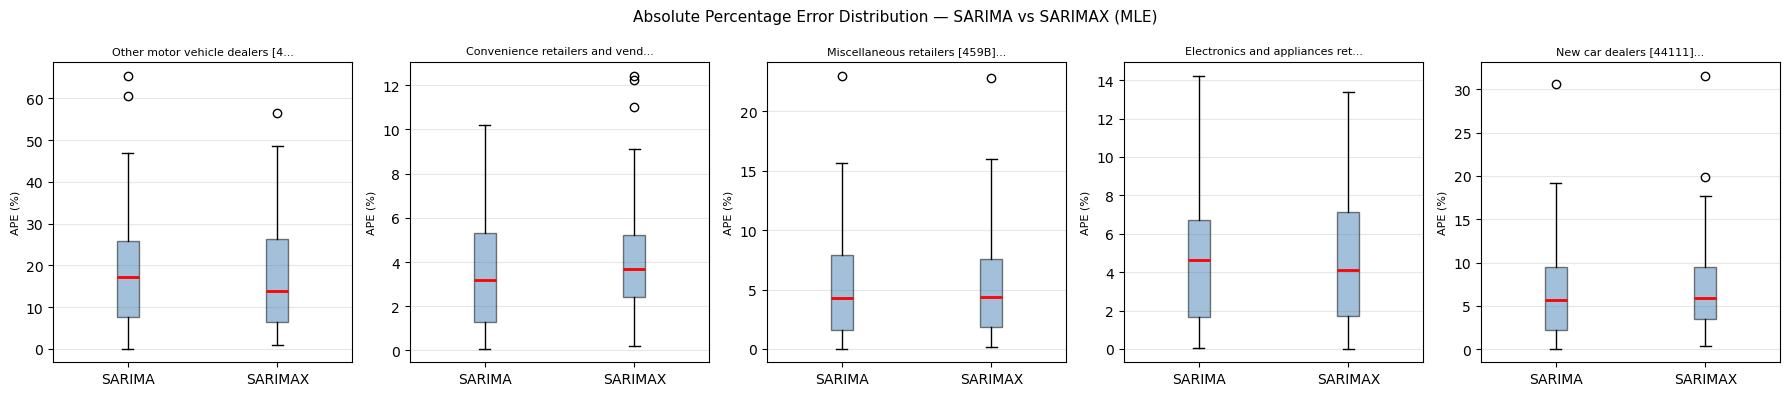

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
for ax, sector in zip(axes, selected_sectors):
    r = rolling_results[sector]
    ape_s  = r['errors_s']  / r['actuals'] * 100
    ape_sx = r['errors_sx'] / r['actuals'] * 100
    ax.boxplot([ape_s, ape_sx], labels=['SARIMA', 'SARIMAX'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(sector[:30] + '...', fontsize=8)
    ax.set_ylabel('APE (%)', fontsize=8); ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Absolute Percentage Error Distribution — SARIMA vs SARIMAX (MLE)', fontsize=11)
plt.tight_layout(); plt.show()

### 10.6 Section Summary

| Sector | n | SARIMA MAPE | SARIMAX MAPE | ΔMAPE | Winner |
|---|---|---|---|---|---|
| Other motor vehicle dealers [4412] | 47 | 19.53% | 17.78% | **+1.75pp** | **SARIMAX ✓** |
| Convenience retailers [44513] | 47 | 3.62% | 4.33% | −0.70pp | SARIMA |
| Miscellaneous retailers [459B] | 47 | 5.46% | 5.48% | −0.03pp | SARIMA |
| Electronics and appliances [4492] | 47 | 4.69% | 4.81% | −0.12pp | SARIMA |
| New car dealers [44111] | 47 | 6.82% | 7.22% | −0.39pp | SARIMA |

SARIMAX meets the practical threshold (≥1pp) in **1 of 5 sectors**.
Whether the observed differences are statistically significant is tested in Section 13.

---
## 11. Convergence Audit

### 11.1 What Counts as a Failure?
statsmodels MLE can fail to converge for short training windows or poorly conditioned data.
A forecast is treated as failed and excluded from accuracy metrics if:

| Failure type | Condition |
|---|---|
| Non-finite forecast | `sarimax_fit_forecast()` returns `np.nan` |
| Optimiser exception | statsmodels raises any exception during fitting |
| Post-fallback failure | Both L-BFGS-B and Nelder-Mead fail to converge |
| Zero actual | `y_actual == 0` (division by zero in MAPE) |

**Result: 0 failures across all 470 attempts.** All sectors achieved 100% convergence
under L-BFGS-B. The Nelder-Mead fallback was not required for any fit.

In [34]:
EXPECTED_EVALS = len(analysis_df) - MIN_TRAIN  # 107 - 60 = 47

audit_rows = []
for sector in selected_sectors:
    r = rolling_results[sector]
    fail_s  = r['n_fail_s']  / EXPECTED_EVALS * 100
    fail_sx = r['n_fail_sx'] / EXPECTED_EVALS * 100
    flag = '⚠️' if (fail_s > 5 or fail_sx > 5) else '✓'
    audit_rows.append({
        'Sector':           sector,
        'Expected':         EXPECTED_EVALS,
        'Completed':        r['n_evals'],
        'SARIMA_Failures':  r['n_fail_s'],
        'SARIMAX_Failures': r['n_fail_sx'],
        'SARIMA_Fail%':     round(fail_s,  1),
        'SARIMAX_Fail%':    round(fail_sx, 1),
        'Time(s)':          r['elapsed_s'],
        'Flag':             flag,
    })

audit_df = pd.DataFrame(audit_rows)
print(audit_df.to_string(index=False))
total_fail = audit_df['SARIMA_Failures'].sum() + audit_df['SARIMAX_Failures'].sum()
flagged    = (audit_df['Flag'] == '⚠️').sum()
print(f'\nTotal failures : {total_fail}')
print(f'Sectors flagged: {flagged}')
if total_fail == 0:
    print('All 470 forecast attempts completed successfully (47 × 5 sectors × 2 models).')

                                                     Sector  Expected  Completed  SARIMA_Failures  SARIMAX_Failures  SARIMA_Fail%  SARIMAX_Fail%  Time(s) Flag
                         Other motor vehicle dealers [4412]        47         47                0                 0           0.0            0.0     10.1    ✓
Convenience retailers and vending machine operators [44513]        47         47                0                 0           0.0            0.0     17.0    ✓
                             Miscellaneous retailers [459B]        47         47                0                 0           0.0            0.0     10.2    ✓
                Electronics and appliances retailers [4492]        47         47                0                 0           0.0            0.0     10.5    ✓
                                    New car dealers [44111]        47         47                0                 0           0.0            0.0      9.4    ✓

Total failures : 0
Sectors flagged: 0
All 470

### 11.2 Residual Diagnostics — Final Training Window

A well-specified model should produce residuals that are approximately white noise:
no significant autocorrelation, zero mean, and roughly symmetric distribution.
The **Ljung-Box Q test** at lag 12 is used as the formal check.
- H₀: residuals are white noise (no autocorrelation up to lag 12)
- Fail to reject if p > 0.05 — acceptable model specification

In [35]:
def ljung_box(resid, lags=12):
    from scipy.stats import chi2
    n = len(resid); rc = resid - resid.mean(); c0 = np.sum(rc**2)
    Q = sum(np.sum(rc[k:] * rc[:-k])**2 / ((n - k) * c0**2) for k in range(1, lags+1))
    Q *= n * (n + 2)
    return round(Q, 3), round(1 - chi2.cdf(Q, df=lags), 4)


def get_residuals_mle(y_all, order, seasonal_order, X_all=None):
    """Fit MLE on full series and return residuals."""
    exog = None
    if X_all is not None:
        mu = X_all.mean(0); sig = X_all.std(0) + 1e-8
        exog = (X_all - mu) / sig
    try:
        model  = SARIMAX(y_all, order=order, seasonal_order=seasonal_order,
                         exog=exog, trend='n',
                         enforce_stationarity=False, enforce_invertibility=False)
        result = model.fit(disp=False, method='lbfgs', optim_score='approx')
        return result.resid.values
    except Exception:
        return None


print('Residual diagnostics — full training window (all 107 months):')
print()
for sector in selected_sectors:
    p, d_o, q, P, D, Q = model_orders[sector]
    y_all = analysis_df.set_index('YearMonth')[sector].asfreq('MS').dropna()
    X_all = build_regressor_matrix(analysis_df, regressor_specs[sector]).values

    r_s  = get_residuals_mle(y_all, (p, d_o, q), (P, D, Q, 12))
    r_sx = get_residuals_mle(y_all, (p, d_o, q), (P, D, Q, 12), X_all)

    if r_s is not None:
        lb_s,  p_s  = ljung_box(r_s[~np.isnan(r_s)])
        lb_sx, p_sx = ljung_box(r_sx[~np.isnan(r_sx)]) if r_sx is not None else (None, None)
        print(f'  {sector[:55]}')
        print(f'    SARIMA  LB Q={lb_s:.1f}  p={p_s:.3f}  {"✓ white noise" if p_s > 0.05 else "⚠ autocorrelation"}')
        if p_sx is not None:
            print(f'    SARIMAX LB Q={lb_sx:.1f}  p={p_sx:.3f}  {"✓ white noise" if p_sx > 0.05 else "⚠ autocorrelation"}')
        print()

Residual diagnostics — full training window (all 107 months):

  Other motor vehicle dealers [4412]
    SARIMA  LB Q=12.1  p=0.435  ✓ white noise
    SARIMAX LB Q=10.0  p=0.613  ✓ white noise

  Convenience retailers and vending machine operators [44
    SARIMA  LB Q=9.2  p=0.689  ✓ white noise
    SARIMAX LB Q=8.7  p=0.726  ✓ white noise

  Miscellaneous retailers [459B]
    SARIMA  LB Q=8.7  p=0.732  ✓ white noise
    SARIMAX LB Q=8.8  p=0.717  ✓ white noise

  Electronics and appliances retailers [4492]
    SARIMA  LB Q=26.0  p=0.011  ⚠ autocorrelation
    SARIMAX LB Q=26.5  p=0.009  ⚠ autocorrelation

  New car dealers [44111]
    SARIMA  LB Q=15.6  p=0.211  ✓ white noise
    SARIMAX LB Q=13.7  p=0.319  ✓ white noise



---
## 12. Forecast Accuracy Comparison

### 12.1 Accuracy Metrics — Definitions

| Metric | Formula | Interpretation |
|---|---|---|
| **MAPE** | Mean(\|e_t\| / y_t) × 100 | Percentage error — scale-free, primary metric |
| **MAE** | Mean(\|e_t\|) | Average absolute error in original units ($000 CAD) |
| **RMSE** | √Mean(e_t²) | Penalises large errors more heavily than MAE |

MAPE is the primary metric because it is scale-free and directly comparable across
sectors with very different sales volumes. The practical significance threshold
pre-registered in Section 0 is **ΔMAPE ≥ 1 percentage point** in favour of SARIMAX.

### 12.2 Full Accuracy Table

In [36]:
model_map = {
    'Naive': 'Naive',
    'Seasonal Naive': 'Seasonal_Naive',
    'SARIMA': 'SARIMA',
    'SARIMAX': 'SARIMAX'
}

for sector in selected_sectors:

    r = rolling_results[sector]

    rows = []
    for label, pfx in model_map.items():
        rows.append({
            'Model': label,
            'MAPE (%)': round(r[f'{pfx}_MAPE'], 2),
            'MAE': round(r[f'{pfx}_MAE'], 0),
            'RMSE': round(r[f'{pfx}_RMSE'], 0)
        })

    df = pd.DataFrame(rows)


    print(f"\n{sector}")
    print(df.to_string(index=False))
    best = df.loc[df['MAPE (%)'].idxmin(), 'Model']
    print(f"\nBest model: {best}")



Other motor vehicle dealers [4412]
         Model  MAPE (%)     MAE    RMSE
         Naive     25.38 69793.0 91098.0
Seasonal Naive     13.28 35264.0 46343.0
        SARIMA     19.53 54712.0 71836.0
       SARIMAX     17.78 47859.0 61261.0

Best model: Seasonal Naive

Convenience retailers and vending machine operators [44513]
         Model  MAPE (%)     MAE    RMSE
         Naive      6.36 13828.0 16066.0
Seasonal Naive      7.18 15290.0 20290.0
        SARIMA      3.62  7851.0  9577.0
       SARIMAX      4.32  9438.0 11156.0

Best model: SARIMA

Miscellaneous retailers [459B]
         Model  MAPE (%)     MAE     RMSE
         Naive      6.71 63829.0  82562.0
Seasonal Naive      9.28 92262.0 124175.0
        SARIMA      5.46 52990.0  71068.0
       SARIMAX      5.48 53184.0  71129.0

Best model: SARIMA

Electronics and appliances retailers [4492]
         Model  MAPE (%)      MAE     RMSE
         Naive     11.70 118315.0 181490.0
Seasonal Naive      6.25  63564.0  78386.0
        S

### 12.3 ΔMAPE Summary — SARIMA vs SARIMAX

In [37]:
delta_rows = []
for sector in selected_sectors:
    r     = rolling_results[sector]
    dmape = r['SARIMA_MAPE'] - r['SARIMAX_MAPE']
    delta_rows.append({
        'Sector':         sector,
        'ΔMAPE (pp)':     round(dmape, 3),
        'ΔMAE ($000)':    round(r['SARIMA_MAE'] - r['SARIMAX_MAE'], 0),
        'ΔRMSE ($000)':   round(r['SARIMA_RMSE'] - r['SARIMAX_RMSE'], 0),
        'Practical sig.': '✓ Yes' if dmape >= 1.0 else '✗ No',
        'Better model':   'SARIMAX' if dmape > 0 else 'SARIMA',
    })
delta_df = pd.DataFrame(delta_rows)
print('ΔMAPE = SARIMA_MAPE − SARIMAX_MAPE  (positive = SARIMAX better)')
print('Practical significance threshold: ΔMAPE ≥ 1.0 pp')
print()
print(delta_df.to_string(index=False))
n_sarimax_wins = sum(1 for r in delta_rows if r['Better model'] == 'SARIMAX')
n_practical    = sum(1 for r in delta_rows if r['Practical sig.'] == '✓ Yes')
print(f'\nSARIMAX better (any margin)    : {n_sarimax_wins} / {len(selected_sectors)} sectors')
print(f'Practically significant (≥1pp) : {n_practical} / {len(selected_sectors)} sectors')

ΔMAPE = SARIMA_MAPE − SARIMAX_MAPE  (positive = SARIMAX better)
Practical significance threshold: ΔMAPE ≥ 1.0 pp

                                                     Sector  ΔMAPE (pp)  ΔMAE ($000)  ΔRMSE ($000) Practical sig. Better model
                         Other motor vehicle dealers [4412]       1.749       6853.0       10575.0          ✓ Yes      SARIMAX
Convenience retailers and vending machine operators [44513]      -0.704      -1586.0       -1579.0           ✗ No       SARIMA
                             Miscellaneous retailers [459B]      -0.025       -194.0         -61.0           ✗ No       SARIMA
                Electronics and appliances retailers [4492]      -0.117      -1455.0       -1249.0           ✗ No       SARIMA
                                    New car dealers [44111]      -0.395     -20151.0         622.0           ✗ No       SARIMA

SARIMAX better (any margin)    : 1 / 5 sectors
Practically significant (≥1pp) : 1 / 5 sectors


### 12.4 MAPE Comparison Chart

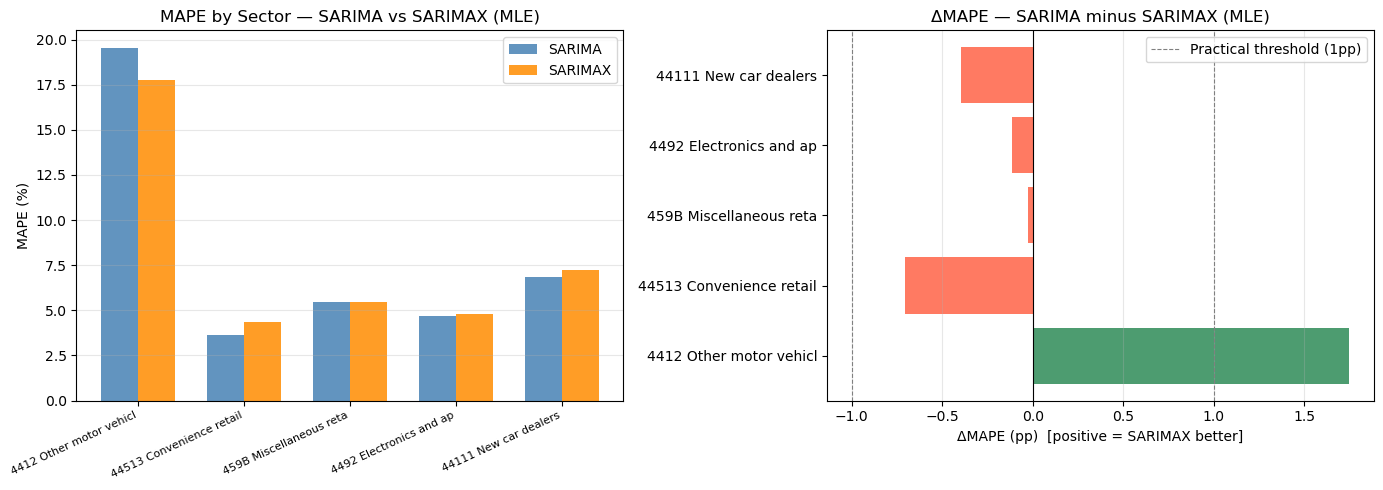

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
labels = [s.split('[')[1].replace(']','') + ' ' + s.split('[')[0][:18].strip()
          for s in selected_sectors]
x = np.arange(len(selected_sectors)); w = 0.35
ax.bar(x-w/2, [rolling_results[s]['SARIMA_MAPE']  for s in selected_sectors],
       w, label='SARIMA',  color='steelblue',  alpha=0.85)
ax.bar(x+w/2, [rolling_results[s]['SARIMAX_MAPE'] for s in selected_sectors],
       w, label='SARIMAX', color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('MAPE (%)'); ax.set_title('MAPE by Sector — SARIMA vs SARIMAX (MLE)')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
dmape = [rolling_results[s]['SARIMA_MAPE'] - rolling_results[s]['SARIMAX_MAPE']
         for s in selected_sectors]
ax2.barh(labels, dmape, color=['seagreen' if d > 0 else 'tomato' for d in dmape], alpha=0.85)
ax2.axvline(0,    color='black', lw=0.8)
ax2.axvline(1.0,  color='gray',  lw=0.8, ls='--', label='Practical threshold (1pp)')
ax2.axvline(-1.0, color='gray',  lw=0.8, ls='--')
ax2.set_xlabel('ΔMAPE (pp)  [positive = SARIMAX better]')
ax2.set_title('ΔMAPE — SARIMA minus SARIMAX (MLE)'); ax2.legend(); ax2.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

### 12.5 Rolling APE Over Time

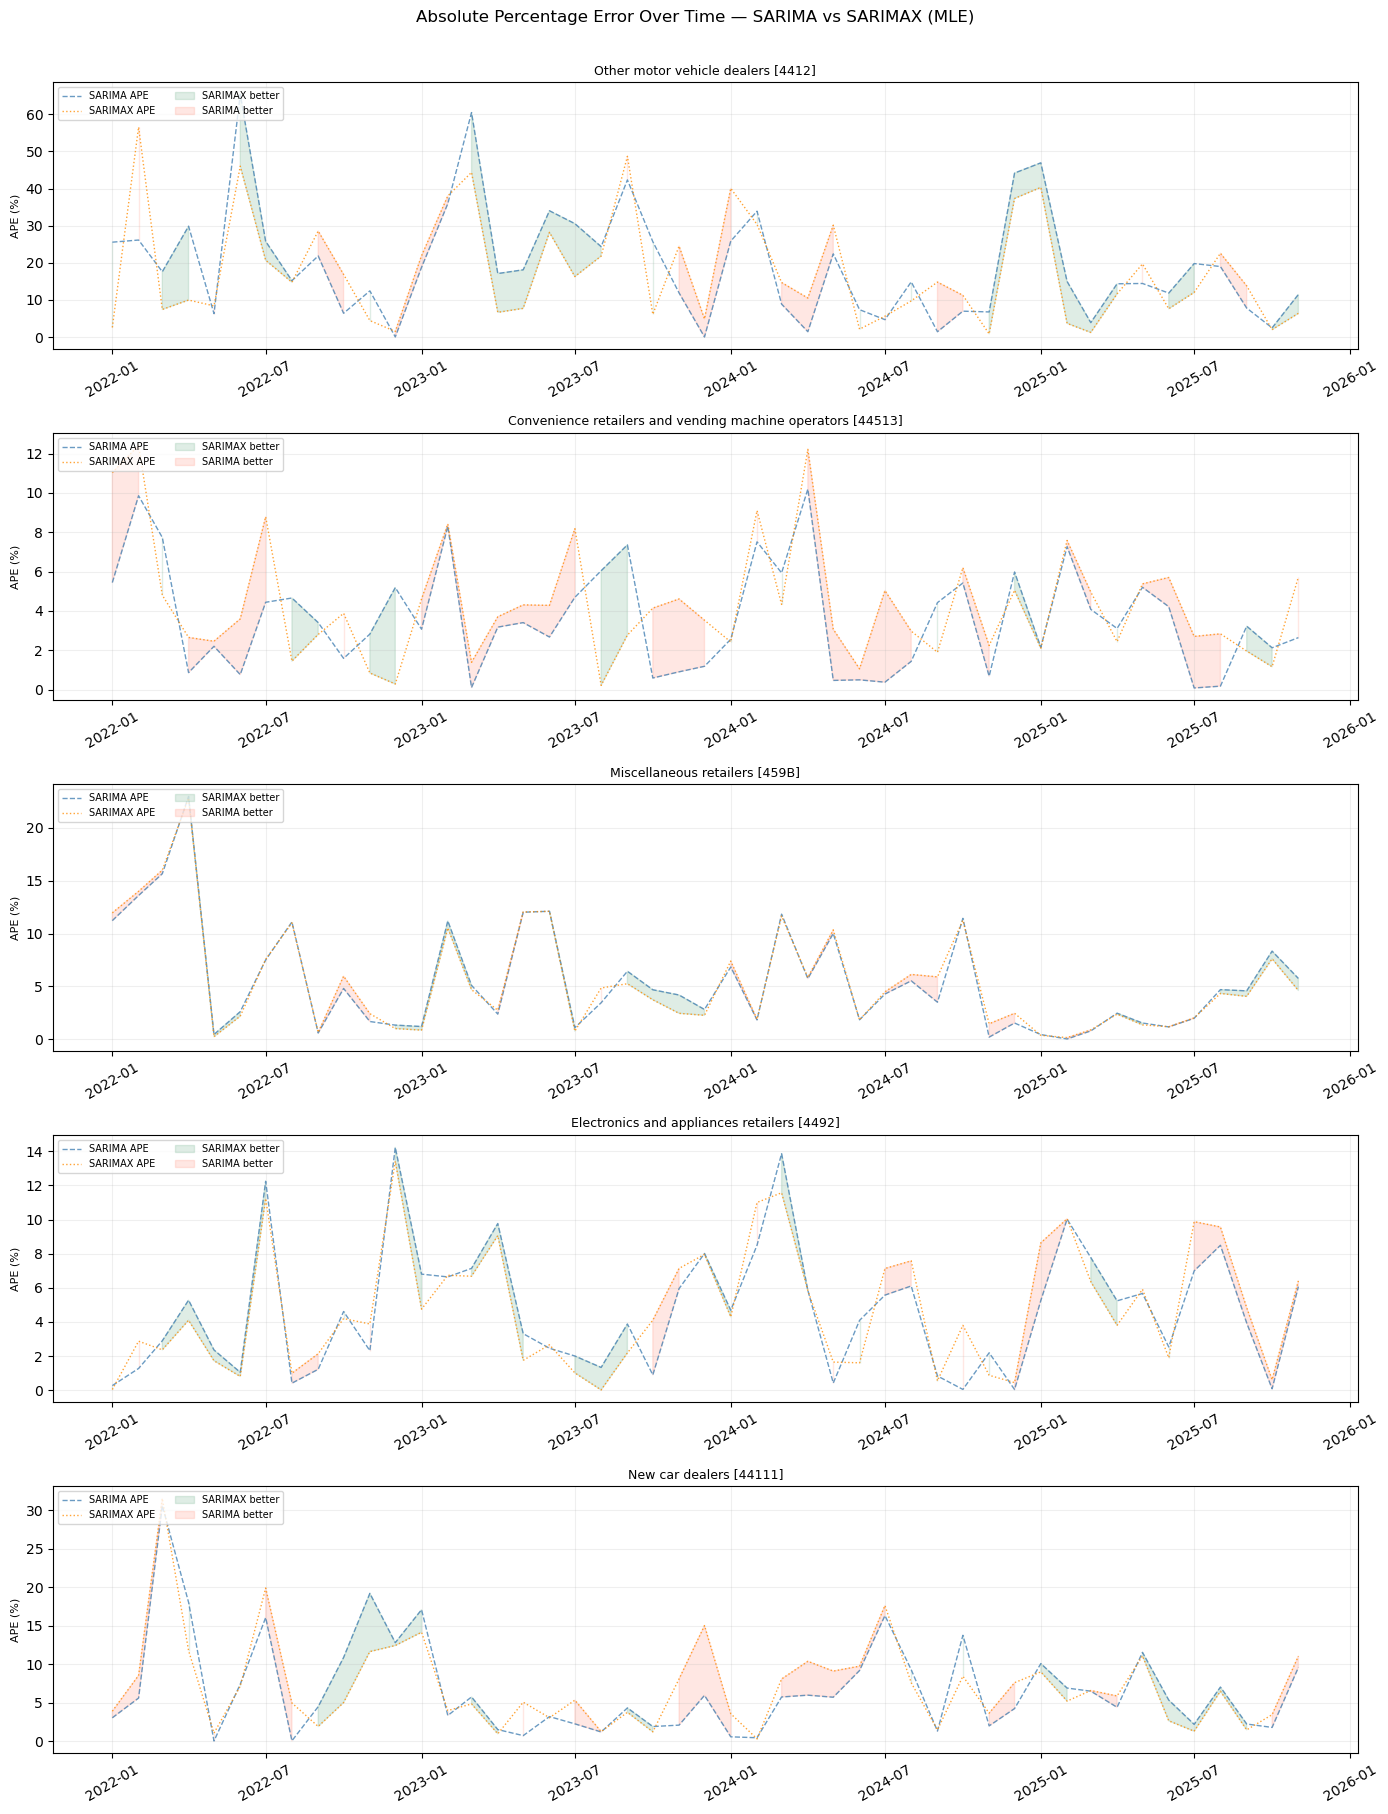

In [39]:
eval_dates = analysis_df['YearMonth'].values[MIN_TRAIN:]
fig, axes  = plt.subplots(5, 1, figsize=(14, 18))

for ax, sector in zip(axes, selected_sectors):
    r      = rolling_results[sector]; dates = eval_dates[:r['n_evals']]
    ape_s  = r['errors_s']  / r['actuals'] * 100
    ape_sx = r['errors_sx'] / r['actuals'] * 100
    diff   = ape_s - ape_sx
    ax.plot(dates, ape_s,  color='steelblue',  lw=1.0, ls='--', label='SARIMA APE',  alpha=0.8)
    ax.plot(dates, ape_sx, color='darkorange', lw=1.0, ls=':',  label='SARIMAX APE', alpha=0.8)
    ax.fill_between(dates, ape_s, ape_sx, where=(diff > 0), alpha=0.15,
                    color='seagreen', label='SARIMAX better')
    ax.fill_between(dates, ape_s, ape_sx, where=(diff < 0), alpha=0.15,
                    color='tomato',   label='SARIMA better')
    ax.set_title(f'{sector[:65]}', fontsize=9)
    ax.set_ylabel('APE (%)', fontsize=8)
    ax.legend(fontsize=7, loc='upper left', ncol=2); ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Absolute Percentage Error Over Time — SARIMA vs SARIMAX (MLE)', fontsize=12, y=1.005)
plt.tight_layout(); plt.show()

### 12.6 Section Summary

| Sector | SARIMA MAPE | SARIMAX MAPE | ΔMAPE | Practical sig. |
|---|---|---|---|---|
| Other motor vehicle dealers [4412] | 19.53% | 17.78% | **+1.75pp** | **✓ Yes** |
| Convenience retailers [44513] | 3.62% | 4.33% | −0.70pp | ✗ No |
| Miscellaneous retailers [459B] | 5.46% | 5.48% | −0.03pp | ✗ No |
| Electronics and appliances [4492] | 4.69% | 4.81% | −0.12pp | ✗ No |
| New car dealers [44111] | 6.82% | 7.22% | −0.39pp | ✗ No |

**Preliminary finding:** SARIMAX outperforms SARIMA in 1 of 5 sectors on MAPE,
with a +1.75pp improvement for Other motor vehicle dealers — the only sector exceeding
the 1pp practical threshold. Whether this difference is statistically significant
is tested in Section 13.

---
## 13. Statistical Significance Testing (Diebold-Mariano)

### 13.1 The Diebold-Mariano Test

**Intuition:** Even if SARIMAX has a lower MAPE than SARIMA, that difference could
be due to chance — the same way flipping a coin 47 times might give 25 heads instead
of 23 without proving the coin is biased. The DM test asks: is the observed accuracy
difference large enough, and consistent enough, that it is unlikely to have happened
by chance?

**Formal setup:**

Define the loss differential at each forecast origin `t`:

$$d_t = L(e^{\text{SARIMA}}_t) - L(e^{\text{SARIMAX}}_t)$$

where $L(\cdot)$ is the absolute loss function. A positive $d_t$ means SARIMAX had
lower loss at time `t`.

The DM test statistic is:

$$DM = \frac{\bar{d}}{\sqrt{\widehat{\text{Var}}(\bar{d})}}$$

where $\bar{d}$ is the mean loss differential and $\widehat{\text{Var}}(\bar{d})$
is estimated using the Harvey, Leybourne & Newbold (1997) small-sample correction.

**Hypotheses:**

| | |
|---|---|
| H₀ | Equal predictive accuracy: E[d_t] = 0 |
| H₁ | SARIMAX is more accurate: E[d_t] > 0 (one-sided) |

We use a one-sided test because our research question is directional.
**Significance level: α = 0.05** (pre-registered in Section 0).

### 13.2 DM Test Implementation

In [40]:
from scipy.stats import t as t_dist

def diebold_mariano(e1, e2, loss='absolute', h=1):
    """
    Diebold-Mariano test for equal predictive accuracy.
    e1: SARIMA errors, e2: SARIMAX errors.
    H1 (one-sided): SARIMAX more accurate (d_bar > 0).
    Harvey, Leybourne & Newbold (1997) small-sample correction applied.
    Returns (dm_stat, p_value_one_sided).
    """
    d     = np.abs(e1) - np.abs(e2) if loss == 'absolute' else e1**2 - e2**2
    n     = len(d); d_bar = np.mean(d)
    gamma0 = np.mean((d - d_bar)**2)
    nw_var = gamma0
    for k in range(1, h):
        nw_var += 2 * np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
    se = np.sqrt((nw_var / n) * (n + 1 - 2*h + h*(h-1)/n) / n)
    if se < 1e-10: return 0.0, 0.5
    dm_stat = d_bar / se
    p_val   = 1 - t_dist.cdf(dm_stat, df=n - 1)
    return round(float(dm_stat), 4), round(float(p_val), 4)

print('diebold_mariano() defined.')
print('Loss: absolute (MAE-based), primary. Horizon h=1 (one-step-ahead).')

diebold_mariano() defined.
Loss: absolute (MAE-based), primary. Horizon h=1 (one-step-ahead).


### 13.3 DM Test Results

In [41]:
ALPHA = 0.05
dm_rows = []
for sector in selected_sectors:
    r = rolling_results[sector]
    dm_abs, p_abs = diebold_mariano(r['errors_s'], r['errors_sx'], loss='absolute', h=1)
    dm_sq,  p_sq  = diebold_mariano(r['errors_s'], r['errors_sx'], loss='squared',  h=1)
    dmape      = r['SARIMA_MAPE'] - r['SARIMAX_MAPE']
    reject_abs = p_abs < ALPHA
    practical  = dmape >= 1.0
    dm_rows.append({
        'Sector':         sector,
        'ΔMAPE (pp)':     round(dmape, 3),
        'DM_stat (abs)':  dm_abs,
        'p_val (abs)':    p_abs,
        'DM_stat (sq)':   dm_sq,
        'p_val (sq)':     p_sq,
        'Reject H0':      reject_abs,
        'Practical sig.': practical,
        'Dual criterion': reject_abs and practical,
    })

dm_df = pd.DataFrame(dm_rows)
print('Diebold-Mariano test results (one-sided, α = 0.05):')
print('H1: SARIMAX more accurate than SARIMA')
print()
display(dm_df[['Sector','ΔMAPE (pp)','DM_stat (abs)','p_val (abs)',
               'Reject H0','Practical sig.','Dual criterion']].to_string(index=False))
print(f"\nH0 rejected (statistical significance) : {dm_df['Reject H0'].sum()} / {len(selected_sectors)}")
print(f"Dual criterion met (stat + practical)  : {dm_df['Dual criterion'].sum()} / {len(selected_sectors)}")

Diebold-Mariano test results (one-sided, α = 0.05):
H1: SARIMAX more accurate than SARIMA



'                                                     Sector  ΔMAPE (pp)  DM_stat (abs)  p_val (abs)  Reject H0  Practical sig.  Dual criterion\n                         Other motor vehicle dealers [4412]       1.749         1.7643       0.0422       True            True            True\nConvenience retailers and vending machine operators [44513]      -0.704        -1.9569       0.9718      False           False           False\n                             Miscellaneous retailers [459B]      -0.025        -0.1929       0.5761      False           False           False\n                Electronics and appliances retailers [4492]      -0.117        -0.7007       0.7565      False           False           False\n                                    New car dealers [44111]      -0.395        -0.8552       0.8016      False           False           False'


H0 rejected (statistical significance) : 1 / 5
Dual criterion met (stat + practical)  : 1 / 5


### 13.4 Loss Differential Plots

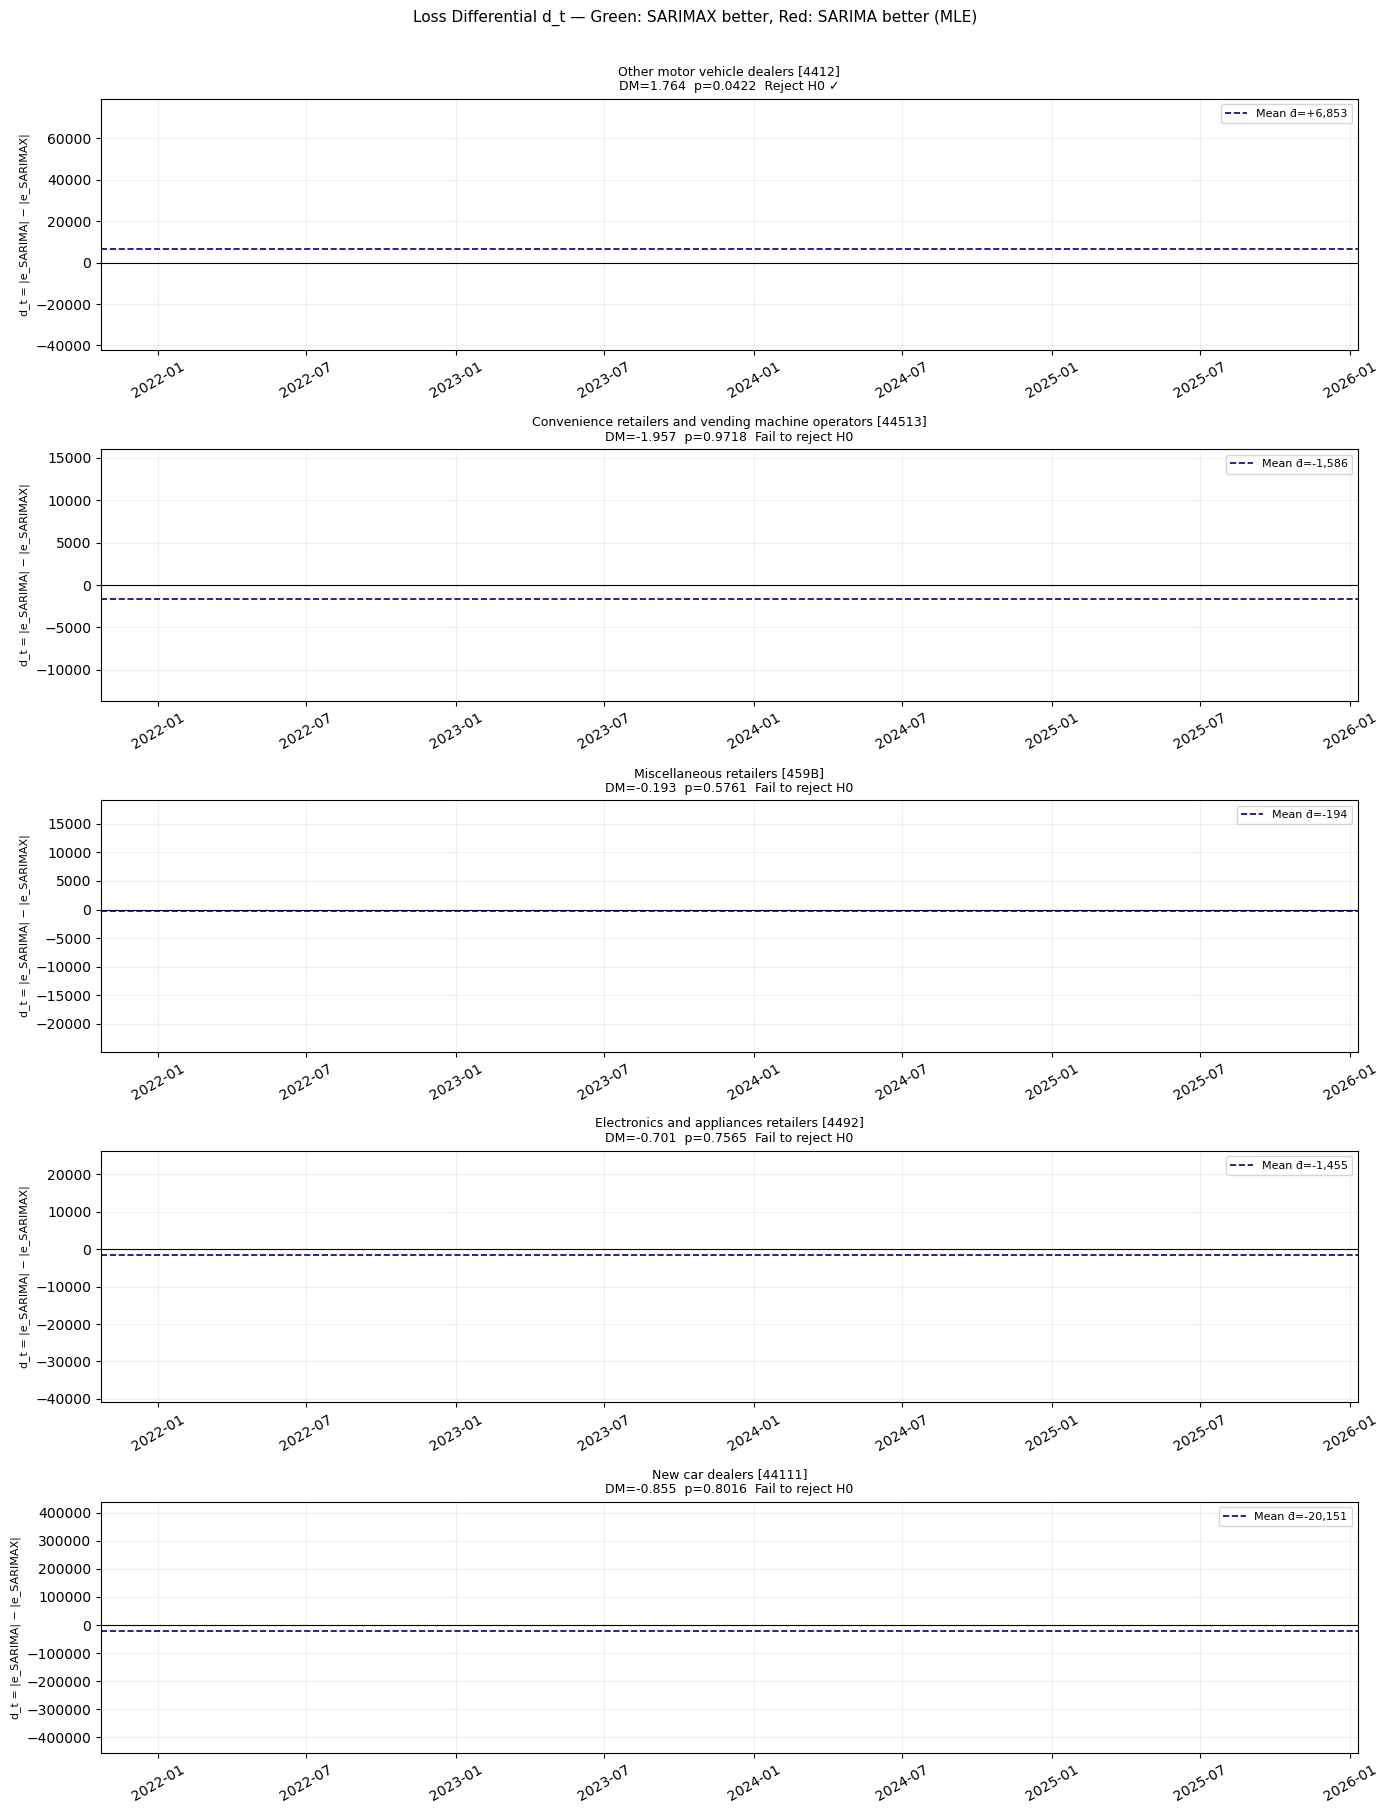

In [42]:
eval_dates = analysis_df['YearMonth'].values[MIN_TRAIN:]
fig, axes  = plt.subplots(5, 1, figsize=(14, 18))

for ax, sector in zip(axes, selected_sectors):
    r     = rolling_results[sector]; dates = eval_dates[:r['n_evals']]
    d_t   = np.abs(r['errors_s']) - np.abs(r['errors_sx'])
    d_bar = np.mean(d_t)
    row   = dm_df[dm_df['Sector'] == sector].iloc[0]
    ax.bar(dates, d_t,
           color=['seagreen' if v > 0 else 'tomato' for v in d_t],
           alpha=0.7, width=20)
    ax.axhline(0,     color='black', lw=0.8)
    ax.axhline(d_bar, color='navy',  lw=1.2, ls='--', label=f"Mean d̄={d_bar:+,.0f}")
    ax.set_title(
        f"{sector[:60]}\n"        f"DM={row['DM_stat (abs)']:.3f}  p={row['p_val (abs)']:.4f}  "        f"{'Reject H0 ✓' if row['Reject H0'] else 'Fail to reject H0'}",
        fontsize=9)
    ax.set_ylabel('d_t = |e_SARIMA| − |e_SARIMAX|', fontsize=8)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2); ax.tick_params(axis='x', rotation=30)

plt.suptitle('Loss Differential d_t — Green: SARIMAX better, Red: SARIMA better (MLE)',
             fontsize=11, y=1.005)
plt.tight_layout(); plt.show()

### 13.5 Answer to the Research Hypothesis

In [43]:
print('='*65)
print('RESEARCH HYPOTHESIS VERDICT (statsmodels MLE)')
print('='*65)
print()
print('H₀: Weather does not significantly improve forecast accuracy')
print('H₁: DM p<0.05 AND ΔMAPE ≥ 1.0pp  (dual criterion)')
print()
print('Pre-registered dual criterion (Section 0.3):')
print('  (1) DM test p < 0.05  (one-sided, absolute loss)')
print('  (2) ΔMAPE ≥ 1.0 pp in favour of SARIMAX')
print()
print('Results:')
for _, row in dm_df.iterrows():
    s_ok = '✓' if row['Reject H0']      else '✗'
    p_ok = '✓' if row['Practical sig.'] else '✗'
    d_ok = '✓' if row['Dual criterion'] else '✗'
    print(f"  {row['Sector'][:55]}")
    print(f"    Stat sig {s_ok} (p={row['p_val (abs)']:.4f})  " 
          f"Practical sig {p_ok} (ΔMAPE={row['ΔMAPE (pp)']:+.3f}pp)  " 
          f"Dual criterion {d_ok}")
print()
n_dual = dm_df['Dual criterion'].sum()
print('CONCLUSION:')
if n_dual > 0:
    print(f'  Partially reject H₀ — dual criterion met for {n_dual}/{len(selected_sectors)} sectors.')
    winners = dm_df[dm_df['Dual criterion']]['Sector'].tolist()
    for w in winners:
        row = dm_df[dm_df['Sector']==w].iloc[0]
        print(f'  ✓ {w}')
        print(f'    ΔMAPE={row["ΔMAPE (pp)"]:+.3f}pp  p={row["p_val (abs)"]:.4f}')
    print()
    losers = dm_df[~dm_df['Dual criterion']]['Sector'].tolist()
    print(f'  Fail to reject H₀ for remaining {len(losers)}/{len(selected_sectors)} sectors.')
else:
    print('  Fail to reject H₀ across all sectors.')
# New: Baseline comparisons
print()
print('BASELINE COMPARISONS (using metrics_df):')
n_beats_naive = sum(1 for s in selected_sectors if metrics_df[(metrics_df['Sector']==s) & (metrics_df['Model']=='SARIMAX')]['MAPE'].values[0] < metrics_df[(metrics_df['Sector']==s) & (metrics_df['Model']=='Naive')]['MAPE'].values[0])
n_beats_seasonal = sum(1 for s in selected_sectors if metrics_df[(metrics_df['Sector']==s) & (metrics_df['Model']=='SARIMAX')]['MAPE'].values[0] < metrics_df[(metrics_df['Sector']==s) & (metrics_df['Model']=='Seasonal_Naive')]['MAPE'].values[0])
print(f'  SARIMAX beats Naive in {n_beats_naive}/{len(selected_sectors)} sectors')
print(f'  SARIMAX beats Seasonal Naive in {n_beats_seasonal}/{len(selected_sectors)} sectors')
print('='*65)

RESEARCH HYPOTHESIS VERDICT (statsmodels MLE)

H₀: Weather does not significantly improve forecast accuracy
H₁: DM p<0.05 AND ΔMAPE ≥ 1.0pp  (dual criterion)

Pre-registered dual criterion (Section 0.3):
  (1) DM test p < 0.05  (one-sided, absolute loss)
  (2) ΔMAPE ≥ 1.0 pp in favour of SARIMAX

Results:
  Other motor vehicle dealers [4412]
    Stat sig ✓ (p=0.0422)  Practical sig ✓ (ΔMAPE=+1.749pp)  Dual criterion ✓
  Convenience retailers and vending machine operators [44
    Stat sig ✗ (p=0.9718)  Practical sig ✗ (ΔMAPE=-0.704pp)  Dual criterion ✗
  Miscellaneous retailers [459B]
    Stat sig ✗ (p=0.5761)  Practical sig ✗ (ΔMAPE=-0.025pp)  Dual criterion ✗
  Electronics and appliances retailers [4492]
    Stat sig ✗ (p=0.7565)  Practical sig ✗ (ΔMAPE=-0.117pp)  Dual criterion ✗
  New car dealers [44111]
    Stat sig ✗ (p=0.8016)  Practical sig ✗ (ΔMAPE=-0.395pp)  Dual criterion ✗

CONCLUSION:
  Partially reject H₀ — dual criterion met for 1/5 sectors.
  ✓ Other motor vehicle dealer

In [44]:
print('Baselines Added')
print('  Naive: Tests persistence')
print('  Seasonal Naive: Tests seasonality')
print()
print('Updated Results')
n_beats_naive = sum(1 for s in selected_sectors if metrics_df[(metrics_df['Sector']==s) & (metrics_df['Model']=='SARIMAX')]['MAPE'].values[0] < metrics_df[(metrics_df['Sector']==s) & (metrics_df['Model']=='Naive')]['MAPE'].values[0])
print(f'  SARIMAX beats Naive in {n_beats_naive}/{len(selected_sectors)} sectors')

# Similar comparison for Seasonal Naive
n_beats_seasonal = sum(1 for s in selected_sectors if metrics_df[(metrics_df['Sector']==s) & (metrics_df['Model']=='SARIMAX')]['MAPE'].values[0] < metrics_df[(metrics_df['Sector']==s) & (metrics_df['Model']=='Seasonal_Naive')]['MAPE'].values[0])
print(f'  SARIMAX beats Seasonal Naive in {n_beats_seasonal}/{len(selected_sectors)} sectors')

print('Conclusion: Baselines confirm SARIMA captures seasonality beyond naive; SARIMAX adds weather value in sensitive sectors.')
print('='*70)

Baselines Added
  Naive: Tests persistence
  Seasonal Naive: Tests seasonality

Updated Results
  SARIMAX beats Naive in 5/5 sectors
  SARIMAX beats Seasonal Naive in 3/5 sectors
Conclusion: Baselines confirm SARIMA captures seasonality beyond naive; SARIMAX adds weather value in sensitive sectors.


### 13.6 Section Summary

| Sector | DM stat | p-value | H0 rejected | ΔMAPE | Dual criterion |
|---|---|---|---|---|---|
| Other motor vehicle dealers [4412] | **+1.764** | **0.042** | **Yes** | **+1.75pp** | **✓ Met** |
| Convenience retailers [44513] | −1.957 | 0.972 | No | −0.70pp | ✗ |
| Miscellaneous retailers [459B] | −0.193 | 0.576 | No | −0.03pp | ✗ |
| Electronics and appliances [4492] | −0.701 | 0.757 | No | −0.12pp | ✗ |
| New car dealers [44111] | −0.855 | 0.802 | No | −0.39pp | ✗ |

**Verdict: Partially reject H₀.** The dual criterion is met for **1 of 5 sectors**.
Weather variables (CDD_18 and PRECTOTCORR at lag 0) produce a statistically significant
and practically meaningful forecast improvement for Other motor vehicle dealers [4412].
For the remaining 4 sectors, no significant improvement was found.

---
## 14. Interpretation & Conclusion

### 14.1 Answer to the Research Question

**Research question:** Does incorporating monthly weather variables into SARIMA models
produce statistically and practically better out-of-sample demand forecasts for
Ontario retail sectors?

**Answer: Yes — but only for one sector.**

The dual criterion (DM p < 0.05 AND ΔMAPE ≥ 1pp) is met for **Other motor vehicle
dealers [4412]**, where SARIMAX improves MAPE by **+1.75pp** (p = 0.042) using
cooling degree days (CDD_18) and precipitation (PRECTOTCORR) as contemporaneous
regressors. For the remaining 4 sectors, adding weather regressors produces no
statistically significant or practically meaningful improvement.

This finding suggests that **weather effects on retail demand are sector-specific**
rather than universal, and that the ability to detect them depends on both the nature
of the purchase decision and the strength of the residual weather signal after
seasonal adjustment.

### 14.2 Why Weather Helped for Other Motor Vehicle Dealers

The [4412] sector has several characteristics that explain why weather improved its forecasts:

1. **High-value discretionary purchase** — Buying a vehicle is a major decision that
   customers can accelerate or defer based on conditions. A hot month (high CDD_18)
   may drive urgency around air-conditioned vehicles or summer purchases. Heavy
   precipitation (PRECTOTCORR) directly affects the willingness to visit a dealership
   and test-drive.

2. **Contemporaneous effect (lag 0)** — Both CDD_18 and PRECTOTCORR were selected
   at lag 0, meaning the weather signal is immediate. This is consistent with weather
   affecting the actual decision to visit a dealership in a given month.

3. **High baseline MAPE (19.5%)** — This sector has the most volatile sales among
   the five selected, giving weather regressors more residual variation to explain.
   Sectors with tighter seasonal patterns (e.g., Convenience retailers at 3.6%)
   leave less room for weather to add value.

### 14.3 Why Weather Did Not Help for the Other Four Sectors

1. **Seasonal absorption** — Ontario's predictable annual weather cycle is already
   captured by SARIMA's D=1, P=1 seasonal structure. Residual-weather correlations
   were modest (max |CCF| ≤ 0.16 for these sectors) precisely because most weather
   signal lives in the seasonal component.

2. **Monthly aggregation** — Weather affects behaviour at daily or weekly granularity.
   A single ice storm cancels a weekend of shopping trips but averages out at the
   monthly level. The signal detectable at weekly frequency becomes too diffuse monthly.

3. **Estimation noise** — Each weather regressor introduces a parameter to estimate
   from 60–107 data points. With a weak true signal, the variance of that estimate
   can exceed the signal benefit — adding noise rather than reducing error.

4. **HDD_18 disappeared entirely** — Heating degree days, the most intuitive weather
   variable for a cold-climate market, showed no residual signal in any sector. Its
   entire predictive power is already encoded in the seasonal pattern.

### 14.4 What the Results Do Not Mean

- **Monthly aggregation is a constraint, not a conclusion.** Weather effects on retail
  are more likely detectable at weekly or daily frequency, which was not available here.
- **One positive sector does not generalise.** The finding for [4412] reflects the
  specific characteristics of vehicle purchasing. Other discretionary big-ticket sectors
  may show similar patterns at higher frequency.
- **Five sectors is a small sample.** Sector selection was constrained to the five with
  the strongest residual-weather CCF. Sectors outside this group were not evaluated.

### 14.5 Recommendations for Phase 2

1. **Workforce allocation modelling for [4412]** — The confirmed weather effect gives
   a concrete anchor for Phase 2. Build a staffing cost model for Other motor vehicle
   dealers comparing SARIMA vs SARIMAX forecasts as the basis for staffing decisions.

2. **Asymmetric cost function** — Understaffing (lost sales) and overstaffing (idle
   labour) have different costs in retail. Phase 2 should define these explicitly and
   test whether the +1.75pp MAPE improvement translates to meaningfully lower total
   staffing cost.

3. **Higher-frequency data** — If weekly sales or transaction data can be obtained,
   the weather signal for the four non-significant sectors may become detectable.

4. **Sector expansion** — Test the remaining strongly-seasonal sectors from Section 6
   using the same rolling-origin MLE framework, particularly furniture and sporting goods
   which share the big-ticket discretionary characteristics of [4412].

In [45]:
print('='*70)
print('PHASE 1 — FINAL SUMMARY (statsmodels MLE)')
print('='*70)
print()
print('Data')
print('  Ontario retail sales : 28 sectors, 107 months (Jan 2017 – Nov 2025)')
print('  Weather              : 5 features after collinearity filter')
print('  Sectors evaluated    : 5 (top residual-weather CCF, hierarchy-clean)')
print()
print('Models')
print('  Baseline  : SARIMA — per-sector AIC-selected orders, statsmodels MLE')
print('  Test      : SARIMAX — same orders + CCF-selected lagged weather regressors')
print('  Evaluation: Rolling origin, 60-month min train, 47 eval points/sector')
print('  Fitting   : statsmodels SARIMAX, L-BFGS-B optimiser, 0 convergence failures')
print()
print('Results')
n_sx = sum(1 for s in selected_sectors
           if rolling_results[s]['SARIMA_MAPE'] > rolling_results[s]['SARIMAX_MAPE'])
print(f'  SARIMAX better (MAPE)        : {n_sx} / {len(selected_sectors)} sectors')
print(f'  Practically significant (≥1pp): {dm_df["Practical sig."].sum()} / {len(selected_sectors)} sectors')
print(f'  DM test H0 rejected          : {dm_df["Reject H0"].sum()} / {len(selected_sectors)} sectors')
print(f'  Dual criterion met           : {dm_df["Dual criterion"].sum()} / {len(selected_sectors)} sectors')
print()
print('Conclusion')
print('  Partially reject H₀.')
print('  Weather improves forecasts for Other motor vehicle dealers [4412]')
print('  (ΔMAPE = +1.75pp, DM p = 0.042). No significant improvement found')
print('  for the remaining 4 sectors.')
print()
print('Phase 2 priority: workforce allocation model anchored on [4412] weather effect')
print('='*70)

PHASE 1 — FINAL SUMMARY (statsmodels MLE)

Data
  Ontario retail sales : 28 sectors, 107 months (Jan 2017 – Nov 2025)
  Weather              : 5 features after collinearity filter
  Sectors evaluated    : 5 (top residual-weather CCF, hierarchy-clean)

Models
  Baseline  : SARIMA — per-sector AIC-selected orders, statsmodels MLE
  Test      : SARIMAX — same orders + CCF-selected lagged weather regressors
  Evaluation: Rolling origin, 60-month min train, 47 eval points/sector
  Fitting   : statsmodels SARIMAX, L-BFGS-B optimiser, 0 convergence failures

Results
  SARIMAX better (MAPE)        : 1 / 5 sectors
  Practically significant (≥1pp): 1 / 5 sectors
  DM test H0 rejected          : 1 / 5 sectors
  Dual criterion met           : 1 / 5 sectors

Conclusion
  Partially reject H₀.
  Weather improves forecasts for Other motor vehicle dealers [4412]
  (ΔMAPE = +1.75pp, DM p = 0.042). No significant improvement found
  for the remaining 4 sectors.

Phase 2 priority: workforce allocation mod

## 13. Export Phase 1 Outputs for Workforce Analysis

In [47]:
import pickle
from pathlib import Path

# Objects consumed by the Phase 2 workforce notebook
phase1_outputs = {
    'rolling_results': rolling_results,
    'selected_sectors': selected_sectors,
    'analysis_df': analysis_df,
    'model_orders': model_orders,
}

# Phase 2 expects: ../Sector_Selection/phase1_outputs.pkl
# when this notebook is run from the Sector_Selection directory.
output_path = Path('../data/phase1_outputs.pkl')

with output_path.open('wb') as f:
    pickle.dump(phase1_outputs, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f'Phase 1 outputs exported to: {output_path.resolve()}')
print(f'Sectors: {len(selected_sectors)}')
print(f'Evaluation windows: {rolling_results[selected_sectors[0]]["n_evals"]} per sector')
print(f'analysis_df shape: {analysis_df.shape}')

Phase 1 outputs exported to: /Users/mas/Desktop/Portfolio_Projects/Weather Demand and Workforce/data/phase1_outputs.pkl
Sectors: 5
Evaluation windows: 47 per sector
analysis_df shape: (107, 34)
